<a href="https://colab.research.google.com/github/AndreaCamasta/AndreaCamasta-sheared-gpt2/blob/main/Sheared_GPT2_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##ROOT DIR setup

In [ ]:
from google.colab import drive
import os, sys

drive.mount('/content/drive', force_remount=True)

ROOT_DIR = "/content/drive/MyDrive/sheared_gpt2_project"
os.makedirs(ROOT_DIR, exist_ok=True)

# So we can import from there
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

print("ROOT_DIR:", ROOT_DIR)
!ls "$ROOT_DIR"

Mounted at /content/drive
ROOT_DIR: /content/drive/MyDrive/sheared_gpt2_project
eval  __init__.py  models  pruning  training  Untitled0.ipynb


##config.py with PruningSpec

In [ ]:
%%writefile {ROOT_DIR}/config.py
from dataclasses import dataclass
from transformers import GPT2Config

@dataclass
class PruningSpec:
    """
    Describes the source and target architecture for pruning.
    """
    # source model sizes
    src_n_layer: int
    src_n_head: int
    src_n_inner: int
    src_n_embd: int

    # target sizes (fixed beforehand)
    tgt_n_layer: int
    tgt_n_head: int
    tgt_n_inner: int
    tgt_n_embd: int

    @property
    def layer_compression(self) -> float:
        return self.tgt_n_layer / self.src_n_layer

    @property
    def head_compression(self) -> float:
        return self.tgt_n_head / self.src_n_head

    @property
    def ffn_compression(self) -> float:
        return self.tgt_n_inner / self.src_n_inner

    @property
    def embd_compression(self) -> float:
        return self.tgt_n_embd / self.src_n_embd


def make_default_pruning_spec(model_name: str = "gpt2") -> PruningSpec:
    """
    Build a default PruningSpec for a given GPT-2 variant.

    For now we target ~50% compression on layers, heads, and FFN width
    while keeping hidden size the same.
    """
    cfg = GPT2Config.from_pretrained(model_name)

    src_n_layer = cfg.n_layer
    src_n_head = cfg.n_head
    # n_inner might be None for some configs; default is 4 * n_embd
    src_n_inner = cfg.n_inner or (4 * cfg.n_embd)
    src_n_embd = cfg.n_embd

    # Example: for gpt2 (12L, 12H, 3072 FFN, 768 embd) → target ~half
    if model_name == "gpt2":
        tgt_n_layer = 6
        tgt_n_head = 6
        tgt_n_inner = 1536
        tgt_n_embd = src_n_embd  # keep hidden size fixed
    else:
        # generic ~50% for other GPT-2 variants
        tgt_n_layer = max(1, src_n_layer // 2)
        tgt_n_head = max(1, src_n_head // 2)
        tgt_n_inner = max(4 * 16, src_n_inner // 2)
        tgt_n_embd = src_n_embd  # hidden-size pruning = future work

    return PruningSpec(
        src_n_layer=src_n_layer,
        src_n_head=src_n_head,
        src_n_inner=src_n_inner,
        src_n_embd=src_n_embd,
        tgt_n_layer=tgt_n_layer,
        tgt_n_head=tgt_n_head,
        tgt_n_inner=tgt_n_inner,
        tgt_n_embd=tgt_n_embd,
    )


Writing /content/drive/MyDrive/sheared_gpt2_project/config.py


Check

In [ ]:
from config import make_default_pruning_spec

spec = make_default_pruning_spec("gpt2")
spec, spec.layer_compression, spec.head_compression, spec.ffn_compression

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

(PruningSpec(src_n_layer=12, src_n_head=12, src_n_inner=3072, src_n_embd=768, tgt_n_layer=6, tgt_n_head=6, tgt_n_inner=1536, tgt_n_embd=768),
 0.5,
 0.5,
 0.5)

##pruning/masks.py - HardConcrete masks

In [ ]:
%%writefile {ROOT_DIR}/pruning/masks.py
import torch
import torch.nn as nn
from typing import Optional

class HardConcreteMask(nn.Module):
    """
    Hard-concrete stochastic gates for structured pruning.

    This implements a differentiable relaxation of Bernoulli gates.
    It can be shaped as (n_layers,), (n_layers, n_heads), etc.
    """

    def __init__(
        self,
        shape,
        init_log_alpha: float = 0.0,
        beta: float = 2.0/3.0,
        gamma: float = -0.1,
        zeta: float = 1.1,
        deterministic: bool = False,
    ):
        """
        Args:
            shape: tuple of ints, the shape of the mask tensor.
            init_log_alpha: initial value for log_alpha parameters.
            beta, gamma, zeta: hard-concrete distribution hyperparameters.
            deterministic: if True, always use the mean gate (no sampling).
        """
        super().__init__()
        self.log_alpha = nn.Parameter(torch.full(shape, init_log_alpha))
        self.beta = beta
        self.gamma = gamma
        self.zeta = zeta
        self.deterministic = deterministic

    def _sample_u(self, like: torch.Tensor) -> torch.Tensor:
        return torch.rand_like(like)

    def _stretched_sigmoid(self, log_alpha: torch.Tensor, u: torch.Tensor) -> torch.Tensor:
        # Logistic noise
        s = torch.sigmoid((torch.log(u) - torch.log(1 - u) + log_alpha) / self.beta)
        # Stretch to (gamma, zeta)
        s_bar = s * (self.zeta - self.gamma) + self.gamma
        # Hard-sigmoid to [0, 1]
        return torch.clamp(s_bar, 0.0, 1.0)

    def sample(self) -> torch.Tensor:
        """
        Sample a mask in (0, 1) with gradient through log_alpha.
        """
        if self.deterministic or not self.training:
            # Use the mean gate: E[z] ≈ sigmoid(log_alpha) stretched & clamped
            u = torch.full_like(self.log_alpha, 0.5)
        else:
            u = self._sample_u(self.log_alpha)

        z = self._stretched_sigmoid(self.log_alpha, u)
        return z

    def forward(self, deterministic: Optional[bool] = None) -> torch.Tensor:
        """
        Return a mask tensor of shape `shape`.

        Args:
            deterministic: override self.deterministic for this call.
        """
        if deterministic is None:
            deterministic = self.deterministic
        if deterministic:
            u = torch.full_like(self.log_alpha, 0.5)
            return self._stretched_sigmoid(self.log_alpha, u)
        else:
            return self.sample()

    @property
    def expected_mask(self) -> torch.Tensor:
        """
        Approximate expected gate under the current log_alpha.
        Useful after training to rank units for pruning.
        """
        with torch.no_grad():
            u = torch.full_like(self.log_alpha, 0.5)
            return self._stretched_sigmoid(self.log_alpha, u)


Writing /content/drive/MyDrive/sheared_gpt2_project/pruning/masks.py


Check

In [ ]:
from pruning.masks import HardConcreteMask
import torch

m = HardConcreteMask((3, 4), init_log_alpha=5.0)
m.train()
print("Sample mask:", m().shape)
print("Expected mask:", m.expected_mask.shape)

Sample mask: torch.Size([3, 4])
Expected mask: torch.Size([3, 4])


##models/masked_gpt2.py - wrapper around GPT-2 with masks

In [ ]:
%%writefile {ROOT_DIR}/models/masked_gpt2.py
import torch
import torch.nn as nn
from transformers import GPT2LMHeadModel
from typing import Optional, Dict

from config import PruningSpec, make_default_pruning_spec
from pruning.masks import HardConcreteMask


class MaskedGPT2LMHeadModel(nn.Module):
    """
    Wrapper around GPT2LMHeadModel that adds learnable structured masks
    (layers, heads, FFN neurons).

    In this initial version, we simply wrap GPT-2 and make sure it runs.
    We'll extend it to actually apply the masks inside each block.
    """

    def __init__(
        self,
        base_model_name: str = "gpt2",
        pruning_spec: Optional[PruningSpec] = None,
    ):
        super().__init__()
        self.base_model_name = base_model_name

        if pruning_spec is None:
            pruning_spec = make_default_pruning_spec(base_model_name)
        self.pruning_spec = pruning_spec

        # Load the pretrained GPT-2 LM head model
        self.gpt2 = GPT2LMHeadModel.from_pretrained(base_model_name)

        n_layer = self.gpt2.config.n_layer
        n_head = self.gpt2.config.n_head
        n_inner = self.gpt2.config.n_inner or (4 * self.gpt2.config.n_embd)

        # Masks (initialized as "keep everything")
        # Large positive init_log_alpha → mask ~1 initially
        self.layer_mask = HardConcreteMask((n_layer,), init_log_alpha=5.0)
        self.head_mask = HardConcreteMask((n_layer, n_head), init_log_alpha=5.0)
        self.ffn_mask = HardConcreteMask((n_layer, n_inner), init_log_alpha=5.0)

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        labels=None,
        **kwargs,
    ):
        """
        For now, just forward to GPT-2 as-is.
        (We will later integrate masks into internal block computations.)
        """
        outputs = self.gpt2(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
            **kwargs,
        )
        return outputs

    def get_mask_stats(self) -> Dict[str, torch.Tensor]:
        """
        Utility to retrieve current expected masks for analysis / pruning.
        """
        return {
            "layer_mask": self.layer_mask.expected_mask.detach().cpu(),
            "head_mask": self.head_mask.expected_mask.detach().cpu(),
            "ffn_mask": self.ffn_mask.expected_mask.detach().cpu(),
        }


Writing /content/drive/MyDrive/sheared_gpt2_project/models/masked_gpt2.py


Sanity check: import and run a tiny forward pass

In [ ]:
import torch
from config import make_default_pruning_spec
from models.masked_gpt2 import MaskedGPT2LMHeadModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

spec = make_default_pruning_spec("gpt2")
print("PruningSpec:", spec)

model = MaskedGPT2LMHeadModel(base_model_name="gpt2", pruning_spec=spec).to(device)
model.eval()

# tiny dummy batch
input_ids = torch.randint(0, 1000, (2, 16), device=device)

with torch.no_grad():
    out = model(input_ids=input_ids, labels=input_ids)

print("Forward pass OK. Loss:", float(out.loss))
print("Mask stats shapes:", {k: v.shape for k, v in model.get_mask_stats().items()})


Using device: cpu
PruningSpec: PruningSpec(src_n_layer=12, src_n_head=12, src_n_inner=3072, src_n_embd=768, tgt_n_layer=6, tgt_n_head=6, tgt_n_inner=1536, tgt_n_embd=768)


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Forward pass OK. Loss: 10.260506629943848
Mask stats shapes: {'layer_mask': torch.Size([12]), 'head_mask': torch.Size([12, 12]), 'ffn_mask': torch.Size([12, 3072])}


If this runs, you now have:

1. A persistent project in Drive

2. Config & mask infrastructure

3. A GPT-2 wrapper with learnable masks

##Add constraint loss: pruning/objective.py

In [ ]:
%%writefile {ROOT_DIR}/pruning/objective.py
import torch
from typing import Dict

from config import PruningSpec
from models.masked_gpt2 import MaskedGPT2LMHeadModel


def pruning_constraint_loss(
    model: MaskedGPT2LMHeadModel,
    spec: PruningSpec,
    lambdas: Dict[str, float],
) -> torch.Tensor:
    """
    Compute a simple constraint loss that encourages the expected number of
    active layers / heads / FFN neurons to match the target architecture.

    Args:
        model: MaskedGPT2LMHeadModel with layer/head/ffn masks.
        spec:  PruningSpec containing src/tgt sizes.
        lambdas: dict with weights, e.g.:
                 {"layer": 1.0, "head": 0.1, "ffn": 0.1,
                  "l1_layer": 0.0, "l1_head": 0.0, "l1_ffn": 0.0}

    Returns:
        A scalar torch.Tensor (constraint loss).
    """
    stats = model.get_mask_stats()
    z_layer = stats["layer_mask"]        # shape [n_layer]
    z_head = stats["head_mask"]          # shape [n_layer, n_head]
    z_ffn = stats["ffn_mask"]            # shape [n_layer, n_inner]

    # Expected counts
    # Layers: sum of layer mask
    L_hat = z_layer.sum()

    # Heads: sum over all layers & heads
    H_hat = z_head.sum()

    # FFN neurons: sum over all layers & intermediate units
    M_hat = z_ffn.sum()

    # Target counts
    L_target = float(spec.tgt_n_layer)
    H_target = float(spec.tgt_n_layer * spec.tgt_n_head)
    M_target = float(spec.tgt_n_layer * spec.tgt_n_inner)

    # Squared error penalties
    loss_layer = (L_hat - L_target) ** 2
    loss_head = (H_hat - H_target) ** 2
    loss_ffn = (M_hat - M_target) ** 2

    # Optional L1 sparsity encouraging lower masks overall
    l1_layer = z_layer.mean()
    l1_head = z_head.mean()
    l1_ffn = z_ffn.mean()

    # Combine with lambdas
    layer_coeff = lambdas.get("layer", 0.0)
    head_coeff = lambdas.get("head", 0.0)
    ffn_coeff = lambdas.get("ffn", 0.0)

    l1_layer_coeff = lambdas.get("l1_layer", 0.0)
    l1_head_coeff = lambdas.get("l1_head", 0.0)
    l1_ffn_coeff = lambdas.get("l1_ffn", 0.0)

    constraint = (
        layer_coeff * loss_layer
        + head_coeff * loss_head
        + ffn_coeff * loss_ffn
        + l1_layer_coeff * l1_layer
        + l1_head_coeff * l1_head
        + l1_ffn_coeff * l1_ffn
    )

    return constraint


Writing /content/drive/MyDrive/sheared_gpt2_project/pruning/objective.py


##Small toy dataset

In [ ]:
%%writefile {ROOT_DIR}/training/data_utils.py
from datasets import load_dataset
from transformers import AutoTokenizer
import torch

def load_tiny_lm_dataset(
    model_name: str = "gpt2",
    split: str = "train",
    max_length: int = 128,
    num_samples: int = 2048,
):
    """
    Load a small language modeling dataset and tokenize it for GPT-2.
    We use wikitext-2-raw-v1 as an example and subsample num_samples sequences.
    """
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.padding_side = "right"
    tokenizer.pad_token = tokenizer.eos_token  # GPT-2 has no pad token by default

    ds = load_dataset("wikitext", "wikitext-2-raw-v1", split=split)
    ds = ds.shuffle(seed=42).select(range(min(num_samples, len(ds))))

    def tokenize_fn(examples):
        return tokenizer(
            examples["text"],
            truncation=True,
            max_length=max_length,
            padding="max_length",
        )

    tokenized = ds.map(tokenize_fn, batched=True, remove_columns=["text"])
    tokenized.set_format(type="torch", columns=["input_ids", "attention_mask"])
    return tokenized, tokenizer


def lm_collate_fn(batch):
    """
    Simple collate: stack input_ids and attention_mask and use input as labels.
    """
    input_ids = torch.stack([b["input_ids"] for b in batch], dim=0)
    attention_mask = torch.stack([b["attention_mask"] for b in batch], dim=0)
    labels = input_ids.clone()
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}


Writing /content/drive/MyDrive/sheared_gpt2_project/training/data_utils.py


##Minimal pruning training loop: training/pruning_trainer.py

In [ ]:
%%writefile {ROOT_DIR}/training/pruning_trainer.py
import torch
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup

from config import make_default_pruning_spec
from models.masked_gpt2 import MaskedGPT2LMHeadModel
from pruning.objective import pruning_constraint_loss
from training.data_utils import load_tiny_lm_dataset, lm_collate_fn


def run_pruning_demo(
    model_name: str = "gpt2",
    batch_size: int = 4,
    max_length: int = 128,
    num_train_steps: int = 100,
    lr: float = 5e-5,
    device: str = "cuda",
):
    """
    Minimal demo training loop for pruning:
    - Loads a tiny LM dataset
    - Wraps GPT-2 with masks
    - Optimizes LM loss + constraint loss for a small number of steps
    """

    spec = make_default_pruning_spec(model_name)
    print("PruningSpec:", spec)

    dataset, tokenizer = load_tiny_lm_dataset(
        model_name=model_name,
        max_length=max_length,
        num_samples=2048,
    )

    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=True, collate_fn=lm_collate_fn
    )

    model = MaskedGPT2LMHeadModel(base_model_name=model_name, pruning_spec=spec)
    model.to(device)
    model.train()

    # Collect all parameters (GPT-2 + masks)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    total_steps = num_train_steps
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )

    # Weights for the constraint terms (you can tune these)
    lambdas = {
        "layer": 1e-3,
        "head": 1e-6,
        "ffn": 1e-6,
        "l1_layer": 0.0,
        "l1_head": 0.0,
        "l1_ffn": 0.0,
    }

    step = 0
    data_iter = iter(dataloader)

    while step < num_train_steps:
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            batch = next(data_iter)

        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],
        )
        lm_loss = outputs.loss

        constr_loss = pruning_constraint_loss(model, spec, lambdas)
        loss = lm_loss + constr_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        if step % 10 == 0:
            print(
                f"Step {step:4d} | "
                f"LM loss: {lm_loss.item():.3f} | "
                f"Constraint loss: {constr_loss.item():.3f} | "
                f"Total: {loss.item():.3f}"
            )

        step += 1

    # After training, print expected active counts for inspection
    stats = model.get_mask_stats()
    z_layer = stats["layer_mask"]
    z_head = stats["head_mask"]
    z_ffn = stats["ffn_mask"]

    L_hat = z_layer.sum().item()
    H_hat = z_head.sum().item()
    M_hat = z_ffn.sum().item()

    print("\nFinal expected counts (approx):")
    print(f"  Layers: {L_hat:.2f} (target {spec.tgt_n_layer})")
    print(f"  Heads:  {H_hat:.2f} (target {spec.tgt_n_layer * spec.tgt_n_head})")
    print(f"  FFN:    {M_hat:.2f} (target {spec.tgt_n_layer * spec.tgt_n_inner})")

    return model, spec, tokenizer


Writing /content/drive/MyDrive/sheared_gpt2_project/training/pruning_trainer.py


##Run the pruning demo loop

In [ ]:
import sys, torch

ROOT_DIR = "/content/drive/MyDrive/sheared_gpt2_project"
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

from training.pruning_trainer import run_pruning_demo

device = "cuda" if torch.cuda.is_available() else "cpu"
model, spec, tokenizer = run_pruning_demo(
    model_name="gpt2",
    batch_size=4,
    max_length=128,
    num_train_steps=50,   # keep small at first
    lr=5e-5,
    device=device,
)


PruningSpec: PruningSpec(src_n_layer=12, src_n_head=12, src_n_inner=3072, src_n_embd=768, tgt_n_layer=6, tgt_n_head=6, tgt_n_inner=1536, tgt_n_embd=768)


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Map:   0%|          | 0/2048 [00:00<?, ? examples/s]

Step    0 | LM loss: 6.330 | Constraint loss: 764.460 | Total: 770.790
Step   10 | LM loss: 2.794 | Constraint loss: 764.460 | Total: 767.253
Step   20 | LM loss: 1.210 | Constraint loss: 764.460 | Total: 765.669
Step   30 | LM loss: 3.293 | Constraint loss: 764.460 | Total: 767.753
Step   40 | LM loss: 2.725 | Constraint loss: 764.460 | Total: 767.185

Final expected counts (approx):
  Layers: 12.00 (target 6)
  Heads:  144.00 (target 36)
  FFN:    36864.00 (target 9216)


##Fixing the problems: overwrite pruning/objective.py

In [ ]:
%%writefile {ROOT_DIR}/pruning/objective.py
import torch
from typing import Dict

from config import PruningSpec
from models.masked_gpt2 import MaskedGPT2LMHeadModel


def pruning_constraint_loss(
    model: MaskedGPT2LMHeadModel,
    spec: PruningSpec,
    lambdas: Dict[str, float],
) -> torch.Tensor:
    """
    Compute a constraint loss that encourages the expected number of
    active layers / heads / FFN neurons to match the target architecture.

    IMPORTANT: we use *live* masks (with gradients), not detached stats.
    """

    # Live masks with gradients
    z_layer = model.layer_mask()          # shape [n_layer]
    z_head = model.head_mask()            # shape [n_layer, n_head]
    z_ffn = model.ffn_mask()              # shape [n_layer, n_inner]

    # Expected counts (sums of mask values)
    L_hat = z_layer.sum()
    H_hat = z_head.sum()
    M_hat = z_ffn.sum()

    # Target counts
    L_target = float(spec.tgt_n_layer)
    H_target = float(spec.tgt_n_layer * spec.tgt_n_head)
    M_target = float(spec.tgt_n_layer * spec.tgt_n_inner)

    # Squared error penalties
    loss_layer = (L_hat - L_target) ** 2
    loss_head = (H_hat - H_target) ** 2
    loss_ffn = (M_hat - M_target) ** 2

    # Optional L1 sparsity encouraging lower masks overall
    l1_layer = z_layer.mean()
    l1_head = z_head.mean()
    l1_ffn = z_ffn.mean()

    # Combine with lambdas
    layer_coeff = lambdas.get("layer", 0.0)
    head_coeff = lambdas.get("head", 0.0)
    ffn_coeff = lambdas.get("ffn", 0.0)

    l1_layer_coeff = lambdas.get("l1_layer", 0.0)
    l1_head_coeff = lambdas.get("l1_head", 0.0)
    l1_ffn_coeff = lambdas.get("l1_ffn", 0.0)

    constraint = (
        layer_coeff * loss_layer
        + head_coeff * loss_head
        + ffn_coeff * loss_ffn
        + l1_layer_coeff * l1_layer
        + l1_head_coeff * l1_head
        + l1_ffn_coeff * l1_ffn
    )

    return constraint


Overwriting /content/drive/MyDrive/sheared_gpt2_project/pruning/objective.py


##Overwrite models/masked_gpt2.py mask inits

In [ ]:
%%writefile {ROOT_DIR}/models/masked_gpt2.py
import torch
import torch.nn as nn
from transformers import GPT2LMHeadModel
from typing import Optional, Dict

from config import PruningSpec, make_default_pruning_spec
from pruning.masks import HardConcreteMask


class MaskedGPT2LMHeadModel(nn.Module):
    """
    Wrapper around GPT2LMHeadModel that adds learnable structured masks
    (layers, heads, FFN neurons).
    """

    def __init__(
        self,
        base_model_name: str = "gpt2",
        pruning_spec: Optional[PruningSpec] = None,
    ):
        super().__init__()
        self.base_model_name = base_model_name

        if pruning_spec is None:
            pruning_spec = make_default_pruning_spec(base_model_name)
        self.pruning_spec = pruning_spec

        # Load the pretrained GPT-2 LM head model
        self.gpt2 = GPT2LMHeadModel.from_pretrained(base_model_name)

        n_layer = self.gpt2.config.n_layer
        n_head = self.gpt2.config.n_head
        n_inner = self.gpt2.config.n_inner or (4 * self.gpt2.config.n_embd)

        # Masks (initialized around 0.5 instead of ~1.0)
        init_log_alpha = 0.0  # ~sigmoid(0) = 0.5 before stretching/clamping
        self.layer_mask = HardConcreteMask((n_layer,), init_log_alpha=init_log_alpha)
        self.head_mask = HardConcreteMask((n_layer, n_head), init_log_alpha=init_log_alpha)
        self.ffn_mask = HardConcreteMask((n_layer, n_inner), init_log_alpha=init_log_alpha)

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        labels=None,
        **kwargs,
    ):
        # For now, masks do not yet modify the internal computation;
        # they only appear in the constraint loss.
        outputs = self.gpt2(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
            **kwargs,
        )
        return outputs

    def get_mask_stats(self) -> Dict[str, torch.Tensor]:
        """
        Utility to retrieve current expected masks for analysis / pruning.
        """
        return {
            "layer_mask": self.layer_mask.expected_mask.detach().cpu(),
            "head_mask": self.head_mask.expected_mask.detach().cpu(),
            "ffn_mask": self.ffn_mask.expected_mask.detach().cpu(),
        }


Overwriting /content/drive/MyDrive/sheared_gpt2_project/models/masked_gpt2.py


##Slightly strengthen the constraint for layers
To see visible movement in just 50–100 steps, let’s bump the layer term a bit:

In [ ]:
%%writefile {ROOT_DIR}/training/pruning_trainer.py
import torch
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup

from config import make_default_pruning_spec
from models.masked_gpt2 import MaskedGPT2LMHeadModel
from pruning.objective import pruning_constraint_loss
from training.data_utils import load_tiny_lm_dataset, lm_collate_fn


def run_pruning_demo(
    model_name: str = "gpt2",
    batch_size: int = 4,
    max_length: int = 128,
    num_train_steps: int = 100,
    lr: float = 5e-5,
    device: str = "cuda",
):
    spec = make_default_pruning_spec(model_name)
    print("PruningSpec:", spec)

    dataset, tokenizer = load_tiny_lm_dataset(
        model_name=model_name,
        max_length=max_length,
        num_samples=2048,
    )

    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=True, collate_fn=lm_collate_fn
    )

    model = MaskedGPT2LMHeadModel(base_model_name=model_name, pruning_spec=spec)
    model.to(device)
    model.train()

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    total_steps = num_train_steps
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )

    # Stronger emphasis on matching layer count (still weak for heads/ffn)
    lambdas = {
        "layer": 1e-2,
        "head": 1e-5,
        "ffn": 1e-7,
        "l1_layer": 0.0,
        "l1_head": 0.0,
        "l1_ffn": 0.0,
    }

    step = 0
    data_iter = iter(dataloader)

    while step < num_train_steps:
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            batch = next(data_iter)

        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],
        )
        lm_loss = outputs.loss

        constr_loss = pruning_constraint_loss(model, spec, lambdas)
        loss = lm_loss + constr_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        if step % 10 == 0:
            print(
                f"Step {step:4d} | "
                f"LM loss: {lm_loss.item():.3f} | "
                f"Constraint loss: {constr_loss.item():.3f} | "
                f"Total: {loss.item():.3f}"
            )

        step += 1

    # Report expected counts using detached stats
    stats = model.get_mask_stats()
    z_layer = stats["layer_mask"]
    z_head = stats["head_mask"]
    z_ffn = stats["ffn_mask"]

    L_hat = z_layer.sum().item()
    H_hat = z_head.sum().item()
    M_hat = z_ffn.sum().item()

    print("\nFinal expected counts (approx):")
    print(f"  Layers: {L_hat:.2f} (target {spec.tgt_n_layer})")
    print(f"  Heads:  {H_hat:.2f} (target {spec.tgt_n_layer * spec.tgt_n_head})")
    print(f"  FFN:    {M_hat:.2f} (target {spec.tgt_n_layer * spec.tgt_n_inner})")

    return model, spec, tokenizer


Overwriting /content/drive/MyDrive/sheared_gpt2_project/training/pruning_trainer.py


##Re-run the pruning demo

In [ ]:
import sys, torch

ROOT_DIR = "/content/drive/MyDrive/sheared_gpt2_project"
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

from training.pruning_trainer import run_pruning_demo

device = "cuda" if torch.cuda.is_available() else "cpu"
model, spec, tokenizer = run_pruning_demo(
    model_name="gpt2",
    batch_size=4,
    max_length=128,
    num_train_steps=100,  # maybe 100–200 to see more movement
    lr=5e-5,
    device=device,
)


PruningSpec: PruningSpec(src_n_layer=12, src_n_head=12, src_n_inner=3072, src_n_embd=768, tgt_n_layer=6, tgt_n_head=6, tgt_n_inner=1536, tgt_n_embd=768)
Step    0 | LM loss: 6.143 | Constraint loss: 764.460 | Total: 770.603
Step   10 | LM loss: 3.569 | Constraint loss: 764.460 | Total: 768.028
Step   20 | LM loss: 2.317 | Constraint loss: 764.460 | Total: 766.776
Step   30 | LM loss: 1.967 | Constraint loss: 764.460 | Total: 766.427
Step   40 | LM loss: 2.216 | Constraint loss: 764.460 | Total: 766.675
Step   50 | LM loss: 1.248 | Constraint loss: 764.460 | Total: 765.707
Step   60 | LM loss: 1.399 | Constraint loss: 764.460 | Total: 765.858
Step   70 | LM loss: 1.501 | Constraint loss: 764.460 | Total: 765.961
Step   80 | LM loss: 1.991 | Constraint loss: 764.460 | Total: 766.450
Step   90 | LM loss: 2.039 | Constraint loss: 764.460 | Total: 766.499

Final expected counts (approx):
  Layers: 12.00 (target 6)
  Heads:  144.00 (target 36)
  FFN:    36864.00 (target 9216)


##Nothing changed: let's restart the runtime a try again
We need to recall a few things

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys

ROOT_DIR = "/content/drive/MyDrive/sheared_gpt2_project"  # adjust if different
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

!ls "$ROOT_DIR"

Mounted at /content/drive
config.py  __init__.py	pruning      training  Untitled0.ipynb
eval	   models	__pycache__  Untitled


Re-import things

In [ ]:
from training.pruning_trainer import run_pruning_demo

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model, spec, tokenizer = run_pruning_demo(
    model_name="gpt2",
    batch_size=2,
    max_length=64,
    num_train_steps=20,  # keep small for quick debug
    lr=5e-5,
    device=device,
)


Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

PruningSpec: PruningSpec(src_n_layer=12, src_n_head=12, src_n_inner=3072, src_n_embd=768, tgt_n_layer=6, tgt_n_head=6, tgt_n_inner=1536, tgt_n_embd=768)


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

...

Map:   0%|          | 0/2048 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step    0 | LM loss: 10.272 | Constraint loss: 8.658 | Total: 18.930
Step   10 | LM loss: 4.231 | Constraint loss: 8.471 | Total: 12.702

Final expected counts (approx):
  Layers: 6.00 (target 6)
  Heads:  71.98 (target 36)
  FFN:    18426.56 (target 9216)


Quick sanity check

In [ ]:
from config import make_default_pruning_spec
from models.masked_gpt2 import MaskedGPT2LMHeadModel
from pruning.objective import pruning_constraint_loss
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

spec = make_default_pruning_spec("gpt2")
model = MaskedGPT2LMHeadModel("gpt2", spec).to(device)
model.train()

lambdas = {"layer": 1e-2, "head": 1e-5, "ffn": 1e-7}

constraint = pruning_constraint_loss(model, spec, lambdas)
constraint.backward()

print("Constraint value:", constraint.item())
print("Grad |layer_mask.log_alpha| mean:",
      model.layer_mask.log_alpha.grad.abs().mean().item())
print("Grad |head_mask.log_alpha| mean:",
      model.head_mask.log_alpha.grad.abs().mean().item())
print("Grad |ffn_mask.log_alpha| mean:",
      model.ffn_mask.log_alpha.grad.abs().mean().item())


Constraint value: 8.529130935668945
Grad |layer_mask.log_alpha| mean: 0.0026268288493156433
Grad |head_mask.log_alpha| mean: 0.00015619516489095986
Grad |ffn_mask.log_alpha| mean: 0.000404057907871902


##Update MaskedGPT2LMHeadModel to use hooks

In [ ]:
%%writefile {ROOT_DIR}/models/masked_gpt2.py
import torch
import torch.nn as nn
from transformers import GPT2LMHeadModel
from typing import Optional, Dict

from config import PruningSpec, make_default_pruning_spec
from pruning.masks import HardConcreteMask


class MaskedGPT2LMHeadModel(nn.Module):
    """
    Wrapper around GPT2LMHeadModel that adds learnable structured masks
    (layers, heads, FFN neurons) and applies the layer mask inside the
    transformer via forward hooks.
    """

    def __init__(
        self,
        base_model_name: str = "gpt2",
        pruning_spec: Optional[PruningSpec] = None,
    ):
        super().__init__()
        self.base_model_name = base_model_name

        if pruning_spec is None:
            pruning_spec = make_default_pruning_spec(base_model_name)
        self.pruning_spec = pruning_spec

        # Load the pretrained GPT-2 LM head model
        self.gpt2 = GPT2LMHeadModel.from_pretrained(base_model_name)

        n_layer = self.gpt2.config.n_layer
        n_head = self.gpt2.config.n_head
        n_inner = self.gpt2.config.n_inner or (4 * self.gpt2.config.n_embd)

        # Masks (initialized around 0.5 instead of ~1.0)
        init_log_alpha = 0.0  # ~sigmoid(0) = 0.5 before stretching/clamping
        self.layer_mask = HardConcreteMask((n_layer,), init_log_alpha=init_log_alpha)
        self.head_mask = HardConcreteMask((n_layer, n_head), init_log_alpha=init_log_alpha)
        self.ffn_mask = HardConcreteMask((n_layer, n_inner), init_log_alpha=init_log_alpha)

        # Storage for current layer mask during a forward pass
        self._current_z_layer = None

        # Register forward hooks on each transformer block to apply layer mask
        self._register_layer_hooks()

    def _register_layer_hooks(self):
        """
        Attach a forward hook to each GPT-2 block that scales its output
        by the corresponding layer mask value z_layer[layer_idx].
        """
        self._hooks = []
        for layer_idx, block in enumerate(self.gpt2.transformer.h):

            def make_hook(i):
                def hook(module, input, output):
                    # output is usually a tensor of shape [B, T, H]
                    z_layer = self._current_z_layer
                    if z_layer is None:
                        return output
                    # scalar for this layer
                    z = z_layer[i]  # shape []
                    # broadcast over batch, seq, hidden dims
                    while z.dim() < output.dim():
                        z = z.unsqueeze(0)
                    return output * z
                return hook

            h = block.register_forward_hook(make_hook(layer_idx))
            self._hooks.append(h)

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        labels=None,
        **kwargs,
    ):
        """
        Compute a forward pass where each transformer block's output is
        scaled by its layer mask value.
        """
        # Sample / compute the current layer mask for this forward pass
        z_layer = self.layer_mask()
        self._current_z_layer = z_layer

        outputs = self.gpt2(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
            **kwargs,
        )

        # Clear for safety
        self._current_z_layer = None
        return outputs

    def get_mask_stats(self) -> Dict[str, torch.Tensor]:
        """
        Utility to retrieve current expected masks for analysis / pruning.
        (Detaches from graph; use only for reporting.)
        """
        return {
            "layer_mask": self.layer_mask.expected_mask.detach().cpu(),
            "head_mask": self.head_mask.expected_mask.detach().cpu(),
            "ffn_mask": self.ffn_mask.expected_mask.detach().cpu(),
        }


Overwriting /content/drive/MyDrive/sheared_gpt2_project/models/masked_gpt2.py


**NOTE: We’re still not using head_mask and ffn_mask in the computation—that’s fine for now.**

Now we restart again to load the file updates we just made. Then test

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sys
ROOT_DIR = "/content/drive/MyDrive/sheared_gpt2_project"
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from training.pruning_trainer import run_pruning_demo
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model, spec, tok = run_pruning_demo(
    model_name="gpt2",
    batch_size=1,
    max_length=32,
    num_train_steps=10,   # small, just to see it works
    lr=5e-5,
    device=device,
)

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


PruningSpec: PruningSpec(src_n_layer=12, src_n_head=12, src_n_inner=3072, src_n_embd=768, tgt_n_layer=6, tgt_n_head=6, tgt_n_inner=1536, tgt_n_embd=768)


Map:   0%|          | 0/2048 [00:00<?, ? examples/s]

AttributeError: 'tuple' object has no attribute 'dim'

Fixes

In [ ]:
%%writefile {ROOT_DIR}/models/masked_gpt2.py
import torch
import torch.nn as nn
from transformers import GPT2LMHeadModel
from typing import Optional, Dict

from config import PruningSpec, make_default_pruning_spec
from pruning.masks import HardConcreteMask


class MaskedGPT2LMHeadModel(nn.Module):
    """
    Wrapper around GPT2LMHeadModel that adds learnable structured masks
    (layers, heads, FFN neurons) and applies the layer mask inside the
    transformer via forward hooks.
    """

    def __init__(
        self,
        base_model_name: str = "gpt2",
        pruning_spec: Optional[PruningSpec] = None,
    ):
        super().__init__()
        self.base_model_name = base_model_name

        if pruning_spec is None:
            pruning_spec = make_default_pruning_spec(base_model_name)
        self.pruning_spec = pruning_spec

        # Load the pretrained GPT-2 LM head model
        self.gpt2 = GPT2LMHeadModel.from_pretrained(base_model_name)

        n_layer = self.gpt2.config.n_layer
        n_head = self.gpt2.config.n_head
        n_inner = self.gpt2.config.n_inner or (4 * self.gpt2.config.n_embd)

        # Masks (initialized around 0.5 instead of ~1.0)
        init_log_alpha = 0.0  # ~sigmoid(0) = 0.5 before stretching/clamping
        self.layer_mask = HardConcreteMask((n_layer,), init_log_alpha=init_log_alpha)
        self.head_mask = HardConcreteMask((n_layer, n_head), init_log_alpha=init_log_alpha)
        self.ffn_mask = HardConcreteMask((n_layer, n_inner), init_log_alpha=init_log_alpha)

        # Storage for current layer mask during a forward pass
        self._current_z_layer = None

        # Register forward hooks on each transformer block to apply layer mask
        self._register_layer_hooks()

    def _register_layer_hooks(self):
        """
        Attach a forward hook to each GPT-2 block that scales its output
        by the corresponding layer mask value z_layer[layer_idx].
        """
        self._hooks = []
        for layer_idx, block in enumerate(self.gpt2.transformer.h):

            def make_hook(i):
                def hook(module, input, output):
                    z_layer = self._current_z_layer
                    if z_layer is None:
                        return output

                    # scalar for this layer
                    z = z_layer[i]  # shape []
                    # We may get a tuple: (hidden_states, present, ...)
                    if isinstance(output, tuple):
                        hidden_states = output[0]
                        # Broadcast z to match hidden_states dims
                        z_b = z
                        while z_b.dim() < hidden_states.dim():
                            z_b = z_b.unsqueeze(0)
                        hidden_states = hidden_states * z_b
                        # Rebuild tuple with scaled hidden_states
                        return (hidden_states,) + output[1:]
                    else:
                        # Single tensor case
                        z_b = z
                        while z_b.dim() < output.dim():
                            z_b = z_b.unsqueeze(0)
                        return output * z_b

                return hook

            h = block.register_forward_hook(make_hook(layer_idx))
            self._hooks.append(h)

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        labels=None,
        **kwargs,
    ):
        """
        Compute a forward pass where each transformer block's output is
        scaled by its layer mask value.
        """
        # Sample / compute the current layer mask for this forward pass
        z_layer = self.layer_mask()
        self._current_z_layer = z_layer

        outputs = self.gpt2(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
            **kwargs,
        )

        # Clear for safety
        self._current_z_layer = None
        return outputs

    def get_mask_stats(self) -> Dict[str, torch.Tensor]:
        """
        Utility to retrieve current expected masks for analysis / pruning.
        (Detaches from graph; use only for reporting.)
        """
        return {
            "layer_mask": self.layer_mask.expected_mask.detach().cpu(),
            "head_mask": self.head_mask.expected_mask.detach().cpu(),
            "ffn_mask": self.ffn_mask.expected_mask.detach().cpu(),
        }


Overwriting /content/drive/MyDrive/sheared_gpt2_project/models/masked_gpt2.py


Re-start

In [ ]:
import sys, torch
from google.colab import drive

drive.mount('/content/drive')

ROOT_DIR = "/content/drive/MyDrive/sheared_gpt2_project"
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

from training.pruning_trainer import run_pruning_demo

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model, spec, tok = run_pruning_demo(
    model_name="gpt2",
    batch_size=1,
    max_length=32,
    num_train_steps=5,   # keep it very small while debugging
    lr=5e-5,
    device=device,
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


PruningSpec: PruningSpec(src_n_layer=12, src_n_head=12, src_n_inner=3072, src_n_embd=768, tgt_n_layer=6, tgt_n_head=6, tgt_n_inner=1536, tgt_n_embd=768)


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step    0 | LM loss: 7.539 | Constraint loss: 8.433 | Total: 15.972

Final expected counts (approx):
  Layers: 6.00 (target 6)
  Heads:  71.99 (target 36)
  FFN:    18430.39 (target 9216)


**RIPARTIRE CHIEDENDO A CHAT DI FARE ANCHE LEARNING DI HEAD E FFN**

##Basic Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, torch

ROOT_DIR = "/content/drive/MyDrive/sheared_gpt2_project"  # adjust if you named it differently
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

!ls "$ROOT_DIR"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
config.py  __init__.py	pruning      training  Untitled0.ipynb
eval	   models	__pycache__  Untitled


Run the pruning demo again (short) to get a trained model and spec:

In [ ]:
from training.pruning_trainer import run_pruning_demo

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model, spec, tok = run_pruning_demo(
    model_name="gpt2",
    batch_size=1,
    max_length=32,
    num_train_steps=5,   # small run is enough for structure testing
    lr=5e-5,
    device=device,
)

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


PruningSpec: PruningSpec(src_n_layer=12, src_n_head=12, src_n_inner=3072, src_n_embd=768, tgt_n_layer=6, tgt_n_head=6, tgt_n_inner=1536, tgt_n_embd=768)


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step    0 | LM loss: 17.572 | Constraint loss: 8.507 | Total: 26.079

Final expected counts (approx):
  Layers: 6.00 (target 6)
  Heads:  71.99 (target 36)
  FFN:    18430.27 (target 9216)


##Advanced builder: prune layers + heads + FFN width

In [ ]:
%%writefile {ROOT_DIR}/models/build_sheared_gpt2_structured.py
import torch
from copy import deepcopy
from transformers import GPT2Config, GPT2LMHeadModel

from config import PruningSpec


def select_top_layers(masked_model, spec: PruningSpec):
    """
    Select which layers to keep based on learned layer_mask.
    Returns sorted indices of layers to keep.
    """
    z_layer = masked_model.layer_mask.expected_mask.detach().cpu()  # [n_layer]
    n_keep = spec.tgt_n_layer

    sorted_idx = torch.argsort(z_layer, descending=True)
    keep_idx = sorted_idx[:n_keep]
    keep_idx, _ = torch.sort(keep_idx)
    return keep_idx


def select_heads_and_ffn(masked_model, spec: PruningSpec, keep_layers):
    """
    For each kept layer, choose which attention heads and FFN neurons to keep
    based on head_mask and ffn_mask.

    Returns:
        heads_to_keep: dict[layer_idx] -> tensor of head indices to keep
        ffn_to_keep:   dict[layer_idx] -> tensor of FFN neuron indices to keep
    """
    z_head = masked_model.head_mask.expected_mask.detach().cpu()  # [L, H]
    z_ffn = masked_model.ffn_mask.expected_mask.detach().cpu()    # [L, M]

    src_n_head = z_head.shape[1]
    src_n_inner = z_ffn.shape[1]

    tgt_n_head = spec.tgt_n_head
    tgt_n_inner = spec.tgt_n_inner

    heads_to_keep = {}
    ffn_to_keep = {}

    for li in keep_layers:
        li = int(li.item())
        # Heads
        head_scores = z_head[li]  # [H]
        if tgt_n_head >= src_n_head:
            keep_h = torch.arange(src_n_head)
        else:
            top_h = torch.argsort(head_scores, descending=True)[:tgt_n_head]
            keep_h, _ = torch.sort(top_h)
        heads_to_keep[li] = keep_h

        # FFN neurons
        ffn_scores = z_ffn[li]  # [M]
        if tgt_n_inner >= src_n_inner:
            keep_m = torch.arange(src_n_inner)
        else:
            top_m = torch.argsort(ffn_scores, descending=True)[:tgt_n_inner]
            keep_m, _ = torch.sort(top_m)
        ffn_to_keep[li] = keep_m

    return heads_to_keep, ffn_to_keep


def build_sheared_gpt2_structured(masked_model, spec: PruningSpec):
    """
    Build a smaller GPT-2 LMHeadModel that:
      - Keeps only top-k layers (layer_mask)
      - Within each kept layer, keeps only top heads (head_mask)
      - Within each kept layer, keeps only top FFN neurons (ffn_mask)

    Uses HuggingFace's prune_heads for attention and manual slicing for MLP.
    """
    device = next(masked_model.parameters()).device
    big_model = masked_model.gpt2
    big_cfg = big_model.config

    # 1) Select layers
    keep_layers = select_top_layers(masked_model, spec)
    n_keep = len(keep_layers)

    # 2) Select heads and FFN units per kept layer
    heads_to_keep, ffn_to_keep = select_heads_and_ffn(masked_model, spec, keep_layers)

    # 3) Build new config: fewer layers, fewer heads, smaller FFN
    cfg_dict = big_cfg.to_dict()
    cfg_dict["n_layer"] = int(n_keep)
    cfg_dict["n_head"] = int(spec.tgt_n_head)
    cfg_dict["n_inner"] = int(spec.tgt_n_inner)
    small_cfg = GPT2Config(**cfg_dict)

    # 4) Initialize the small model
    small_model = GPT2LMHeadModel(small_cfg).to(device)

    # Copy shared components: token embeddings, positional embeddings, ln_f, lm_head
    small_model.transformer.wte.load_state_dict(big_model.transformer.wte.state_dict())
    small_model.transformer.wpe.load_state_dict(big_model.transformer.wpe.state_dict())
    small_model.transformer.ln_f.load_state_dict(big_model.transformer.ln_f.state_dict())
    small_model.lm_head.load_state_dict(big_model.lm_head.state_dict())

    # 5) For each kept layer: build pruned blocks and copy into small_model
    for new_i, old_i in enumerate(keep_layers):
        old_i = int(old_i.item())
        old_block = big_model.transformer.h[old_i]
        new_block = small_model.transformer.h[new_i]

        # --- Attention: prune heads structurally ---
        # Deepcopy the old attention so we don't mutate the original
        temp_attn = deepcopy(old_block.attn)

        src_heads = list(range(temp_attn.num_heads))
        keep_h = heads_to_keep[old_i].tolist()
        heads_to_prune = sorted(set(src_heads) - set(keep_h))

        if len(heads_to_prune) > 0:
            temp_attn.prune_heads(heads_to_prune)

        # Now temp_attn has num_heads = spec.tgt_n_head, with weights pruned
        new_block.attn.load_state_dict(temp_attn.state_dict())

        # --- MLP: prune FFN neurons by slicing weights ---
        old_mlp = old_block.mlp
        new_mlp = new_block.mlp

        keep_m = ffn_to_keep[old_i]

        # c_fc: [n_inner, n_embd]
        old_c_fc_w = old_mlp.c_fc.weight.data    # (M, H)
        old_c_fc_b = old_mlp.c_fc.bias.data      # (M,)
        new_mlp.c_fc.weight.data = old_c_fc_w[keep_m, :]
        new_mlp.c_fc.bias.data = old_c_fc_b[keep_m]

        # c_proj: [n_embd, n_inner]
        old_c_proj_w = old_mlp.c_proj.weight.data  # (H, M)
        old_c_proj_b = old_mlp.c_proj.bias.data    # (H,)
        new_mlp.c_proj.weight.data = old_c_proj_w[:, keep_m]
        new_mlp.c_proj.bias.data = old_c_proj_b

        # --- Layer norms and residual projections (unchanged shapes) ---
        new_block.ln_1.load_state_dict(old_block.ln_1.state_dict())
        new_block.ln_2.load_state_dict(old_block.ln_2.state_dict())

    return small_model, keep_layers, heads_to_keep, ffn_to_keep

Writing /content/drive/MyDrive/sheared_gpt2_project/models/build_sheared_gpt2_structured.py


##Build the fully sheared GPT-2 (layers + heads + FFN)

In [ ]:
from models.build_sheared_gpt2_structured import build_sheared_gpt2_structured

small_model_struct, keep_layers, heads_to_keep, ffn_to_keep = build_sheared_gpt2_structured(
    model, spec
)

print("Kept layers (original indices):", keep_layers.tolist())
print("Example (first kept layer) heads kept:", heads_to_keep[int(keep_layers[0].item())].tolist())
print("Example (first kept layer) FFN units kept:", ffn_to_keep[int(keep_layers[0].item())].shape[0])
print("Small model config: n_layer =", small_model_struct.config.n_layer,
      "| n_head =", small_model_struct.config.n_head,
      "| n_inner =", small_model_struct.config.n_inner)

Does not work, masking heads means we have to also reduce the hidden dimension (n_embd) and adjust embeddings, layer norms, projections, etc. That’s a lot of surgery. Thus, we keep structurally prune layers + FFN width, keep all heads.

##Overwrite the builder: prune layers + FFN, keep heads

In [ ]:
%%writefile {ROOT_DIR}/models/build_sheared_gpt2_structured.py
import torch
from transformers import GPT2Config, GPT2LMHeadModel

from config import PruningSpec


def select_top_layers(masked_model, spec: PruningSpec):
    """
    Select which layers to keep based on learned layer_mask.
    Returns sorted indices of layers to keep.
    """
    z_layer = masked_model.layer_mask.expected_mask.detach().cpu()  # [n_layer]
    n_keep = spec.tgt_n_layer

    sorted_idx = torch.argsort(z_layer, descending=True)
    keep_idx = sorted_idx[:n_keep]
    keep_idx, _ = torch.sort(keep_idx)
    return keep_idx


def select_ffn(masked_model, spec: PruningSpec, keep_layers):
    """
    For each kept layer, choose which FFN neurons to keep
    based on ffn_mask. Heads are NOT structurally pruned here.
    """
    z_ffn = masked_model.ffn_mask.expected_mask.detach().cpu()    # [L, M]

    src_n_inner = z_ffn.shape[1]
    tgt_n_inner = spec.tgt_n_inner

    ffn_to_keep = {}

    for li in keep_layers:
        li = int(li.item())
        ffn_scores = z_ffn[li]  # [M]
        if tgt_n_inner >= src_n_inner:
            keep_m = torch.arange(src_n_inner)
        else:
            top_m = torch.argsort(ffn_scores, descending=True)[:tgt_n_inner]
            keep_m, _ = torch.sort(top_m)
        ffn_to_keep[li] = keep_m

    return ffn_to_keep


def build_sheared_gpt2_layers_ffn(masked_model, spec: PruningSpec):
    """
    Build a smaller GPT-2 LMHeadModel that:
      - Keeps only top-k layers (layer_mask)
      - Within each kept layer, keeps only top FFN neurons (ffn_mask)
      - Keeps ALL attention heads structurally (no head pruning)

    This avoids mismatches in attention weight shapes while still
    achieving significant parameter reduction via layers + FFN width.
    """
    device = next(masked_model.parameters()).device
    big_model = masked_model.gpt2
    big_cfg = big_model.config

    # 1) Select layers
    keep_layers = select_top_layers(masked_model, spec)
    n_keep = len(keep_layers)

    # 2) Select FFN units per kept layer
    ffn_to_keep = select_ffn(masked_model, spec, keep_layers)

    # 3) Build new config: fewer layers, smaller FFN, same n_head / n_embd
    cfg_dict = big_cfg.to_dict()
    cfg_dict["n_layer"] = int(n_keep)
    cfg_dict["n_inner"] = int(spec.tgt_n_inner)
    # We KEEP n_head and n_embd as in the original
    cfg_dict["n_head"] = big_cfg.n_head
    cfg_dict["n_embd"] = big_cfg.n_embd

    small_cfg = GPT2Config(**cfg_dict)

    # 4) Initialize the small model
    small_model = GPT2LMHeadModel(small_cfg).to(device)

    # Copy shared components: token embeddings, positional embeddings, ln_f, lm_head
    small_model.transformer.wte.load_state_dict(big_model.transformer.wte.state_dict())
    small_model.transformer.wpe.load_state_dict(big_model.transformer.wpe.state_dict())
    small_model.transformer.ln_f.load_state_dict(big_model.transformer.ln_f.state_dict())
    small_model.lm_head.load_state_dict(big_model.lm_head.state_dict())

    # 5) For each kept layer: copy attention as-is, prune MLP
    for new_i, old_i in enumerate(keep_layers):
        old_i = int(old_i.item())
        old_block = big_model.transformer.h[old_i]
        new_block = small_model.transformer.h[new_i]

        # --- Attention: copy weights directly (no head pruning) ---
        new_block.attn.load_state_dict(old_block.attn.state_dict())

        # --- MLP: prune FFN neurons by slicing weights ---
        old_mlp = old_block.mlp
        new_mlp = new_block.mlp

        keep_m = ffn_to_keep[old_i]

        # c_fc: [n_inner, n_embd]
        old_c_fc_w = old_mlp.c_fc.weight.data    # (M, H)
        old_c_fc_b = old_mlp.c_fc.bias.data      # (M,)
        new_mlp.c_fc.weight.data = old_c_fc_w[keep_m, :]
        new_mlp.c_fc.bias.data = old_c_fc_b[keep_m]

        # c_proj: [n_embd, n_inner]
        old_c_proj_w = old_mlp.c_proj.weight.data  # (H, M)
        old_c_proj_b = old_mlp.c_proj.bias.data    # (H,)
        new_mlp.c_proj.weight.data = old_c_proj_w[:, keep_m]
        new_mlp.c_proj.bias.data = old_c_proj_b

        # --- Layer norms (unchanged shapes) ---
        new_block.ln_1.load_state_dict(old_block.ln_1.state_dict())
        new_block.ln_2.load_state_dict(old_block.ln_2.state_dict())

    return small_model, keep_layers, ffn_to_keep

Overwriting /content/drive/MyDrive/sheared_gpt2_project/models/build_sheared_gpt2_structured.py


##Build the sheared model

In [ ]:
from models.build_sheared_gpt2_structured import build_sheared_gpt2_layers_ffn

small_model_struct, keep_layers, ffn_to_keep = build_sheared_gpt2_layers_ffn(
    model, spec
)

print("Kept layers (original indices):", keep_layers.tolist())
print("Example FFN kept units for first kept layer:",
      ffn_to_keep[int(keep_layers[0].item())].shape[0])
print("Small model config:",
      "n_layer =", small_model_struct.config.n_layer,
      "| n_head =", small_model_struct.config.n_head,
      "| n_inner =", small_model_struct.config.n_inner,
      "| n_embd =", small_model_struct.config.n_embd)

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


Overwrite the builder to operate on CPU

In [ ]:
%%writefile {ROOT_DIR}/models/build_sheared_gpt2_structured.py
import torch
from transformers import GPT2Config, GPT2LMHeadModel

from config import PruningSpec


def select_top_layers(masked_model, spec: PruningSpec):
    """
    Select which layers to keep based on learned layer_mask.
    Returns sorted indices of layers to keep.
    """
    z_layer = masked_model.layer_mask.expected_mask.detach().cpu()  # [n_layer]
    n_keep = spec.tgt_n_layer

    sorted_idx = torch.argsort(z_layer, descending=True)
    keep_idx = sorted_idx[:n_keep]
    keep_idx, _ = torch.sort(keep_idx)
    return keep_idx


def select_ffn(masked_model, spec: PruningSpec, keep_layers):
    """
    For each kept layer, choose which FFN neurons to keep
    based on ffn_mask. Heads are NOT structurally pruned here.
    """
    z_ffn = masked_model.ffn_mask.expected_mask.detach().cpu()    # [L, M]

    src_n_inner = z_ffn.shape[1]
    tgt_n_inner = spec.tgt_n_inner

    ffn_to_keep = {}

    for li in keep_layers:
        li = int(li.item())
        ffn_scores = z_ffn[li]  # [M]
        if tgt_n_inner >= src_n_inner:
            keep_m = torch.arange(src_n_inner)
        else:
            top_m = torch.argsort(ffn_scores, descending=True)[:tgt_n_inner]
            keep_m, _ = torch.sort(top_m)
        ffn_to_keep[li] = keep_m
    return ffn_to_keep


def build_sheared_gpt2_layers_ffn(masked_model, spec: PruningSpec):
    """
    Build a smaller GPT-2 LMHeadModel that:
      - Keeps only top-k layers (layer_mask)
      - Within each kept layer, keeps only top FFN neurons (ffn_mask)
      - Keeps ALL attention heads structurally (no head pruning)

    All weight slicing/copying is done on CPU to avoid CUDA indexing issues.
    """
    device = next(masked_model.parameters()).device
    big_model = masked_model.gpt2
    big_cfg = big_model.config

    # 1) Select layers
    keep_layers = select_top_layers(masked_model, spec)
    n_keep = len(keep_layers)

    # 2) Select FFN units per kept layer
    ffn_to_keep = select_ffn(masked_model, spec, keep_layers)

    # 3) Build new config: fewer layers, smaller FFN, same n_head / n_embd
    cfg_dict = big_cfg.to_dict()
    cfg_dict["n_layer"] = int(n_keep)
    cfg_dict["n_inner"] = int(spec.tgt_n_inner)
    cfg_dict["n_head"] = big_cfg.n_head
    cfg_dict["n_embd"] = big_cfg.n_embd

    small_cfg = GPT2Config(**cfg_dict)

    # 4) Initialize the small model on CPU
    small_model = GPT2LMHeadModel(small_cfg)

    # 5) Copy shared components (embeddings, ln_f, lm_head) on CPU
    with torch.no_grad():
        # Token embeddings
        small_model.transformer.wte.load_state_dict(
            {k: v.detach().cpu() for k, v in big_model.transformer.wte.state_dict().items()}
        )
        # Positional embeddings
        small_model.transformer.wpe.load_state_dict(
            {k: v.detach().cpu() for k, v in big_model.transformer.wpe.state_dict().items()}
        )
        # Final layer norm
        small_model.transformer.ln_f.load_state_dict(
            {k: v.detach().cpu() for k, v in big_model.transformer.ln_f.state_dict().items()}
        )
        # LM head
        small_model.lm_head.load_state_dict(
            {k: v.detach().cpu() for k, v in big_model.lm_head.state_dict().items()}
        )

        # 6) For each kept layer: copy attention as-is, prune MLP
        for new_i, old_i in enumerate(keep_layers):
            old_i = int(old_i.item())
            old_block = big_model.transformer.h[old_i]
            new_block = small_model.transformer.h[new_i]

            # --- Attention: copy weights directly (no head pruning) ---
            new_block.attn.load_state_dict(
                {k: v.detach().cpu() for k, v in old_block.attn.state_dict().items()}
            )

            # --- MLP: prune FFN neurons by slicing weights ---
            old_mlp = old_block.mlp
            new_mlp = new_block.mlp

            keep_m = ffn_to_keep[old_i]

            # c_fc: [n_inner, n_embd]
            old_c_fc_w = old_mlp.c_fc.weight.detach().cpu()    # (M, H)
            old_c_fc_b = old_mlp.c_fc.bias.detach().cpu()      # (M,)
            new_mlp.c_fc.weight.copy_(old_c_fc_w[keep_m, :])
            new_mlp.c_fc.bias.copy_(old_c_fc_b[keep_m])

            # c_proj: [n_embd, n_inner]
            old_c_proj_w = old_mlp.c_proj.weight.detach().cpu()  # (H, M)
            old_c_proj_b = old_mlp.c_proj.bias.detach().cpu()    # (H,)
            new_mlp.c_proj.weight.copy_(old_c_proj_w[:, keep_m])
            new_mlp.c_proj.bias.copy_(old_c_proj_b)

            # --- Layer norms ---
            new_block.ln_1.load_state_dict(
                {k: v.detach().cpu() for k, v in old_block.ln_1.state_dict().items()}
            )
            new_block.ln_2.load_state_dict(
                {k: v.detach().cpu() for k, v in old_block.ln_2.state_dict().items()}
            )

    # Finally move small model back to original device (GPU/CPU)
    small_model = small_model.to(device)
    return small_model, keep_layers, ffn_to_keep

Overwriting /content/drive/MyDrive/sheared_gpt2_project/models/build_sheared_gpt2_structured.py


Run with new builder

In [ ]:
from models.build_sheared_gpt2_structured import build_sheared_gpt2_layers_ffn

small_model_struct, keep_layers, ffn_to_keep = build_sheared_gpt2_layers_ffn(
    model, spec
)

print("Kept layers (original indices):", keep_layers.tolist())
print("Example FFN kept units for first kept layer:",
      ffn_to_keep[int(keep_layers[0].item())].shape[0])
print("Small model config:",
      "n_layer =", small_model_struct.config.n_layer,
      "| n_head =", small_model_struct.config.n_head,
      "| n_inner =", small_model_struct.config.n_inner,
      "| n_embd =", small_model_struct.config.n_embd)

IndexError: index 769 is out of bounds for dimension 0 with size 768

Correct the FFN slicing

In [ ]:
%%writefile {ROOT_DIR}/models/build_sheared_gpt2_structured.py
import torch
from transformers import GPT2Config, GPT2LMHeadModel

from config import PruningSpec


def select_top_layers(masked_model, spec: PruningSpec):
    """
    Select which layers to keep based on learned layer_mask.
    Returns sorted indices of layers to keep.
    """
    z_layer = masked_model.layer_mask.expected_mask.detach().cpu()  # [n_layer]
    n_keep = spec.tgt_n_layer

    sorted_idx = torch.argsort(z_layer, descending=True)
    keep_idx = sorted_idx[:n_keep]
    keep_idx, _ = torch.sort(keep_idx)
    return keep_idx


def select_ffn(masked_model, spec: PruningSpec, keep_layers):
    """
    For each kept layer, choose which FFN neurons to keep
    based on ffn_mask. Heads are NOT structurally pruned here.
    """
    z_ffn = masked_model.ffn_mask.expected_mask.detach().cpu()    # [L, M]

    src_n_inner = z_ffn.shape[1]
    tgt_n_inner = spec.tgt_n_inner

    ffn_to_keep = {}

    for li in keep_layers:
        li = int(li.item())
        ffn_scores = z_ffn[li]  # [M]
        if tgt_n_inner >= src_n_inner:
            keep_m = torch.arange(src_n_inner)
        else:
            top_m = torch.argsort(ffn_scores, descending=True)[:tgt_n_inner]
            keep_m, _ = torch.sort(top_m)
        ffn_to_keep[li] = keep_m
    return ffn_to_keep


def build_sheared_gpt2_layers_ffn(masked_model, spec: PruningSpec):
    """
    Build a smaller GPT-2 LMHeadModel that:
      - Keeps only top-k layers (layer_mask)
      - Within each kept layer, keeps only top FFN neurons (ffn_mask)
      - Keeps ALL attention heads structurally (no head pruning)

    All weight slicing/copying is done on CPU to avoid CUDA indexing issues.
    """
    device = next(masked_model.parameters()).device
    big_model = masked_model.gpt2
    big_cfg = big_model.config

    # 1) Select layers
    keep_layers = select_top_layers(masked_model, spec)
    n_keep = len(keep_layers)

    # 2) Select FFN units per kept layer
    ffn_to_keep = select_ffn(masked_model, spec, keep_layers)

    # 3) Build new config: fewer layers, smaller FFN, same n_head / n_embd
    cfg_dict = big_cfg.to_dict()
    cfg_dict["n_layer"] = int(n_keep)
    cfg_dict["n_inner"] = int(spec.tgt_n_inner)
    cfg_dict["n_head"] = big_cfg.n_head
    cfg_dict["n_embd"] = big_cfg.n_embd

    small_cfg = GPT2Config(**cfg_dict)

    # 4) Initialize the small model on CPU
    small_model = GPT2LMHeadModel(small_cfg)

    # 5) Copy shared components (embeddings, ln_f, lm_head) on CPU
    with torch.no_grad():
        # Token embeddings
        small_model.transformer.wte.load_state_dict(
            {k: v.detach().cpu() for k, v in big_model.transformer.wte.state_dict().items()}
        )
        # Positional embeddings
        small_model.transformer.wpe.load_state_dict(
            {k: v.detach().cpu() for k, v in big_model.transformer.wpe.state_dict().items()}
        )
        # Final layer norm
        small_model.transformer.ln_f.load_state_dict(
            {k: v.detach().cpu() for k, v in big_model.transformer.ln_f.state_dict().items()}
        )
        # LM head
        small_model.lm_head.load_state_dict(
            {k: v.detach().cpu() for k, v in big_model.lm_head.state_dict().items()}
        )

        # 6) For each kept layer: copy attention as-is, prune MLP
        for new_i, old_i in enumerate(keep_layers):
            old_i = int(old_i.item())
            old_block = big_model.transformer.h[old_i]
            new_block = small_model.transformer.h[new_i]

            # --- Attention: copy weights directly (no head pruning) ---
            new_block.attn.load_state_dict(
                {k: v.detach().cpu() for k, v in old_block.attn.state_dict().items()}
            )

            # --- MLP: prune FFN neurons by slicing weights ---
            old_mlp = old_block.mlp
            new_mlp = new_block.mlp

            keep_m = ffn_to_keep[old_i]  # indices in [0, src_n_inner)

            # c_fc.weight: [n_embd, n_inner]  (H, M)
            # c_fc.bias:   [n_inner]
            old_c_fc_w = old_mlp.c_fc.weight.detach().cpu()
            old_c_fc_b = old_mlp.c_fc.bias.detach().cpu()

            # new_mlp.c_fc.weight: [n_embd, tgt_n_inner]
            new_mlp.c_fc.weight.copy_(old_c_fc_w[:, keep_m])
            new_mlp.c_fc.bias.copy_(old_c_fc_b[keep_m])

            # c_proj.weight: [n_inner, n_embd]  (M, H)
            # c_proj.bias:   [n_embd]
            old_c_proj_w = old_mlp.c_proj.weight.detach().cpu()
            old_c_proj_b = old_mlp.c_proj.bias.detach().cpu()

            # new_mlp.c_proj.weight: [tgt_n_inner, n_embd]
            new_mlp.c_proj.weight.copy_(old_c_proj_w[keep_m, :])
            new_mlp.c_proj.bias.copy_(old_c_proj_b)

            # --- Layer norms ---
            new_block.ln_1.load_state_dict(
                {k: v.detach().cpu() for k, v in old_block.ln_1.state_dict().items()}
            )
            new_block.ln_2.load_state_dict(
                {k: v.detach().cpu() for k, v in old_block.ln_2.state_dict().items()}
            )

    # Finally move small model back to original device (GPU/CPU)
    small_model = small_model.to(device)
    return small_model, keep_layers, ffn_to_keep

Overwriting /content/drive/MyDrive/sheared_gpt2_project/models/build_sheared_gpt2_structured.py


Will the builder run this time?

In [ ]:
from models.build_sheared_gpt2_structured import build_sheared_gpt2_layers_ffn

small_model_struct, keep_layers, ffn_to_keep = build_sheared_gpt2_layers_ffn(
    model, spec
)

print("Kept layers (original indices):", keep_layers.tolist())
print("Example FFN kept units for first kept layer:",
      ffn_to_keep[int(keep_layers[0].item())].shape[0])
print("Small model config:",
      "n_layer =", small_model_struct.config.n_layer,
      "| n_head =", small_model_struct.config.n_head,
      "| n_inner =", small_model_struct.config.n_inner,
      "| n_embd =", small_model_struct.config.n_embd)

Kept layers (original indices): [2, 3, 6, 8, 9, 10]
Example FFN kept units for first kept layer: 1536
Small model config: n_layer = 6 | n_head = 12 | n_inner = 1536 | n_embd = 768


In [ ]:
save_dir = f"{ROOT_DIR}/sheared_gpt2_layers_ffn"
import os
os.makedirs(save_dir, exist_ok=True)

small_model_struct.save_pretrained(save_dir)
tok.save_pretrained(save_dir)


('/content/drive/MyDrive/sheared_gpt2_project/sheared_gpt2_layers_ffn/tokenizer_config.json',
 '/content/drive/MyDrive/sheared_gpt2_project/sheared_gpt2_layers_ffn/special_tokens_map.json',
 '/content/drive/MyDrive/sheared_gpt2_project/sheared_gpt2_layers_ffn/vocab.json',
 '/content/drive/MyDrive/sheared_gpt2_project/sheared_gpt2_layers_ffn/merges.txt',
 '/content/drive/MyDrive/sheared_gpt2_project/sheared_gpt2_layers_ffn/added_tokens.json',
 '/content/drive/MyDrive/sheared_gpt2_project/sheared_gpt2_layers_ffn/tokenizer.json')

##Time for a small model evaluation - Create eval file
Now we have the desired architecture and we test it before doing the real pruning

In [ ]:
%%writefile {ROOT_DIR}/training/eval_utils.py
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
from datasets import load_dataset

def count_params(model):
    """Return parameter count (int)."""
    return sum(p.numel() for p in model.parameters())

def compute_perplexity(model, tokenizer, max_samples=200, max_length=128, batch_size=4, device="cuda"):
    """
    Compute perplexity on a small subset of wikitext-2 validation.
    This is not a full benchmark, but enough for comparison.
    """
    model.eval()
    tokenizer.pad_token = tokenizer.eos_token
    dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="validation")
    dataset = dataset.select(range(min(max_samples, len(dataset))))

    def encode(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=max_length,
            padding="max_length",
        )
    tokenized = dataset.map(encode, batched=True, remove_columns=["text"])
    tokenized.set_format(type="torch", columns=["input_ids", "attention_mask"])

    dataloader = DataLoader(tokenized, batch_size=batch_size)

    total_loss = 0
    total_tokens = 0
    loss_fct = torch.nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id, reduction="sum")

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = input_ids.clone()

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            # HF returns mean loss; we need sum of log-likelihoods
            loss = outputs.loss * input_ids.numel() / batch["input_ids"].shape[0]
            total_loss += loss.item()
            total_tokens += attention_mask.sum().item()

    ppl = torch.exp(torch.tensor(total_loss / total_tokens))
    return ppl.item()


def benchmark_generation(model, tokenizer, device="cuda", prompt="The future of AI is", max_new_tokens=50):
    """
    Measure tokens per second for greedy generation.
    Simple but effective benchmark.
    """
    model.eval()

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    # Warm-up
    with torch.no_grad():
        _ = model.generate(**inputs, max_new_tokens=10)

    # Benchmark
    import time
    start = time.time()
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens)
    end = time.time()

    elapsed = end - start
    tokens_generated = max_new_tokens
    tps = tokens_generated / elapsed

    text = tokenizer.decode(out[0], skip_special_tokens=True)
    return tps, text

Writing /content/drive/MyDrive/sheared_gpt2_project/training/eval_utils.py


Evaluate original GPT-2

In [ ]:
from transformers import GPT2LMHeadModel, AutoTokenizer
from training.eval_utils import count_params, compute_perplexity, benchmark_generation

# Load baseline GPT-2
base_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
base_tok = AutoTokenizer.from_pretrained("gpt2")
base_tok.pad_token = base_tok.eos_token

print("Baseline GPT-2 params (M):", count_params(base_model) / 1e6)

# Perplexity
ppl_base = compute_perplexity(base_model, base_tok, device=device, max_samples=200)
print("Baseline GPT-2 Perplexity:", ppl_base)

# Speed
tps_base, text_base = benchmark_generation(base_model, base_tok, device=device)
print("Baseline tokens/sec:", tps_base)
print("\nSample output:\n", text_base)

Baseline GPT-2 params (M): 124.439808


Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Baseline GPT-2 Perplexity: 150.85704040527344


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Baseline tokens/sec: 105.58598491694957

Sample output:
 The future of AI is uncertain. The future of AI is uncertain.

The future of AI is uncertain. The future of AI is uncertain.

The future of AI is uncertain. The future of AI is uncertain.

The future of AI is uncertain.


Evaluate sheared GPT-2

In [ ]:
save_dir = f"{ROOT_DIR}/sheared_gpt2_layers_ffn"

sheared_model = GPT2LMHeadModel.from_pretrained(save_dir).to(device)
sheared_tok = AutoTokenizer.from_pretrained(save_dir)
sheared_tok.pad_token = sheared_tok.eos_token

print("Sheared GPT-2 params (M):", count_params(sheared_model) / 1e6)

# Perplexity
ppl_sheared = compute_perplexity(sheared_model, sheared_tok, device=device, max_samples=200)
print("Sheared GPT-2 Perplexity:", ppl_sheared)

# Speed
tps_sheared, text_sheared = benchmark_generation(sheared_model, sheared_tok, device=device)
print("Sheared tokens/sec:", tps_sheared)
print("\nSheared Output:\n", text_sheared)

Sheared GPT-2 params (M): 67.747584


Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sheared GPT-2 Perplexity: 106.96065521240234
Sheared tokens/sec: 151.49274917378506

Sheared Output:
 The future of AI is the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the


##Time for the real experiment: Overwrite training/pruning_trainer.py with checkpoint support

What this new function does:

Uses WikiText-2 train as pruning data (more samples than our toy demo).

Saves to checkpoint_dir/latest.pt every save_every steps.

On the next run, if resume=True and the checkpoint exists, it:

loads model, optimizer, scheduler, and step

continues from step+1 up to num_train_steps.

In [ ]:
%%writefile {ROOT_DIR}/training/pruning_trainer.py
import os
import torch
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup

from config import make_default_pruning_spec
from models.masked_gpt2 import MaskedGPT2LMHeadModel
from pruning.objective import pruning_constraint_loss
from training.data_utils import load_tiny_lm_dataset, lm_collate_fn


def run_pruning_demo(
    model_name: str = "gpt2",
    batch_size: int = 4,
    max_length: int = 128,
    num_train_steps: int = 100,
    lr: float = 5e-5,
    device: str = "cuda",
):
    """
    Original small demo loop, kept for quick sanity checks.
    """
    spec = make_default_pruning_spec(model_name)
    print("PruningSpec:", spec)

    dataset, tokenizer = load_tiny_lm_dataset(
        model_name=model_name,
        max_length=max_length,
        num_samples=2048,
    )

    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=True, collate_fn=lm_collate_fn
    )

    model = MaskedGPT2LMHeadModel(base_model_name=model_name, pruning_spec=spec)
    model.to(device)
    model.train()

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    total_steps = num_train_steps
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )

    lambdas = {
        "layer": 1e-2,
        "head": 1e-5,
        "ffn": 1e-7,
        "l1_layer": 0.0,
        "l1_head": 0.0,
        "l1_ffn": 0.0,
    }

    step = 0
    data_iter = iter(dataloader)

    while step < num_train_steps:
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            batch = next(data_iter)

        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],
        )
        lm_loss = outputs.loss

        constr_loss = pruning_constraint_loss(model, spec, lambdas)
        loss = lm_loss + constr_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        if step % 10 == 0:
            print(
                f"Step {step:4d} | "
                f"LM loss: {lm_loss.item():.3f} | "
                f"Constraint loss: {constr_loss.item():.3f} | "
                f"Total: {loss.item():.3f}"
            )

        step += 1

    # Report expected counts using detached stats
    stats = model.get_mask_stats()
    z_layer = stats["layer_mask"]
    z_head = stats["head_mask"]
    z_ffn = stats["ffn_mask"]

    L_hat = z_layer.sum().item()
    H_hat = z_head.sum().item()
    M_hat = z_ffn.sum().item()

    print("\nFinal expected counts (approx):")
    print(f"  Layers: {L_hat:.2f} (target {spec.tgt_n_layer})")
    print(f"  Heads:  {H_hat:.2f} (target {spec.tgt_n_layer * spec.tgt_n_head})")
    print(f"  FFN:    {M_hat:.2f} (target {spec.tgt_n_layer * spec.tgt_n_inner})")

    return model, spec, tokenizer


def run_pruning_with_checkpoints(
    model_name: str = "gpt2",
    batch_size: int = 4,
    max_length: int = 128,
    num_train_steps: int = 5000,
    lr: float = 3e-5,
    device: str = "cuda",
    checkpoint_dir: str = "./checkpoints_gpt2_pruning",
    save_every: int = 500,
    resume: bool = True,
):
    """
    Long-run pruning loop with checkpointing.

    - Uses WikiText-2 (train split) as LM data.
    - Can resume from the last checkpoint in checkpoint_dir.
    - Optimizes LM loss + constraint loss toward a fixed target architecture.
    """
    os.makedirs(checkpoint_dir, exist_ok=True)
    ckpt_path = os.path.join(checkpoint_dir, "latest.pt")

    # 1) Build pruning spec and load dataset/tokenizer
    spec = make_default_pruning_spec(model_name)
    print("PruningSpec:", spec)

    dataset, tokenizer = load_tiny_lm_dataset(
        model_name=model_name,
        max_length=max_length,
        num_samples=8192,  # use more samples than the demo
    )

    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=True, collate_fn=lm_collate_fn
    )

    # 2) Initialize model, optimizer, scheduler
    model = MaskedGPT2LMHeadModel(base_model_name=model_name, pruning_spec=spec)
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    total_steps = num_train_steps
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )

    # 3) Try to resume from checkpoint
    start_step = 0
    if resume and os.path.exists(ckpt_path):
        print(f"Loading checkpoint from: {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        scheduler.load_state_dict(ckpt["scheduler"])
        start_step = ckpt.get("step", 0) + 1
        print(f"Resuming from step {start_step}")

    if start_step >= num_train_steps:
        print("Checkpoint already at or beyond requested num_train_steps. Nothing to do.")
        model.eval()
        return model, spec, tokenizer

    # 4) Loss weights
    lambdas = {
        "layer": 1e-2,
        "head": 1e-5,
        "ffn": 1e-7,
        "l1_layer": 0.0,
        "l1_head": 0.0,
        "l1_ffn": 0.0,
    }

    step = start_step
    data_iter = iter(dataloader)

    print(f"Starting pruning run from step {step} to {num_train_steps}...")
    while step < num_train_steps:
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            batch = next(data_iter)

        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],
        )
        lm_loss = outputs.loss

        constr_loss = pruning_constraint_loss(model, spec, lambdas)
        loss = lm_loss + constr_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        if step % 100 == 0:
            print(
                f"Step {step:6d} | "
                f"LM loss: {lm_loss.item():.3f} | "
                f"Constraint loss: {constr_loss.item():.3f} | "
                f"Total: {loss.item():.3f}"
            )

        # 5) Save checkpoint periodically
        if (step + 1) % save_every == 0 or (step + 1) == num_train_steps:
            ckpt = {
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "step": step,
                "spec_model_name": model_name,
            }
            torch.save(ckpt, ckpt_path)
            print(f"[Checkpoint] Saved at step {step} → {ckpt_path}")

        step += 1

    # 6) Final mask stats
    model.eval()
    stats = model.get_mask_stats()
    z_layer = stats["layer_mask"]
    z_head = stats["head_mask"]
    z_ffn = stats["ffn_mask"]

    L_hat = z_layer.sum().item()
    H_hat = z_head.sum().item()
    M_hat = z_ffn.sum().item()

    print("\nFinal expected counts (approx):")
    print(f"  Layers: {L_hat:.2f} (target {spec.tgt_n_layer})")
    print(f"  Heads:  {H_hat:.2f} (target {spec.tgt_n_layer * spec.tgt_n_head})")
    print(f"  FFN:    {M_hat:.2f} (target {spec.tgt_n_layer * spec.tgt_n_inner})")

    return model, spec, tokenizer

Overwriting /content/drive/MyDrive/sheared_gpt2_project/training/pruning_trainer.py


###First session: start from scratch
This will:

run up to step 1999,

saving checkpoints every 200 steps,

and print mask stats at the end.

If Colab disconnects earlier, the last checkpoint is still on Drive.

In [ ]:
from training.pruning_trainer import run_pruning_with_checkpoints
from google.colab import drive
drive.mount('/content/drive')

import os, sys, torch
ROOT_DIR = "/content/drive/MyDrive/sheared_gpt2_project"
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

checkpoint_dir = f"{ROOT_DIR}/checkpoints_gpt2_pruning"

model, spec, tok = run_pruning_with_checkpoints(
    model_name="gpt2",
    batch_size=2,
    max_length=128,
    num_train_steps=2000,    # e.g. aim for 2k steps in first run
    lr=3e-5,
    device=device,
    checkpoint_dir=checkpoint_dir,
    save_every=200,
    resume=True,
)

###Next session: resume and extend

Because resume=True and the checkpoint is at step ~2000:

It will load step 1999

Continue from step 2000 to 4999

Save checkpoints along the way.

If you later want to go to 10,000 steps, just call with num_train_steps=10000.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, torch
ROOT_DIR = "/content/drive/MyDrive/sheared_gpt2_project"
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

from training.pruning_trainer import run_pruning_with_checkpoints

device = "cuda" if torch.cuda.is_available() else "cpu"
checkpoint_dir = f"{ROOT_DIR}/checkpoints_gpt2_pruning"

# Now aim for 5000 total steps (not +5000, but total target)
model, spec, tok = run_pruning_with_checkpoints(
    model_name="gpt2",
    batch_size=2,
    max_length=128,
    num_train_steps=5000,   # total target steps
    lr=3e-5,
    device=device,
    checkpoint_dir=checkpoint_dir,
    save_every=200,
    resume=True,
)

##After the long run: rebuild the sheared model

In [ ]:
from models.build_sheared_gpt2_structured import build_sheared_gpt2_layers_ffn

small_model_struct, keep_layers, ffn_to_keep = build_sheared_gpt2_layers_ffn(
    model, spec
)

print("Kept layers:", keep_layers.tolist())
print("Small model config:",
      "n_layer =", small_model_struct.config.n_layer,
      "| n_inner =", small_model_struct.config.n_inner)

###Now reload and setup, then run a small check test, then real training

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, torch

ROOT_DIR = "/content/drive/MyDrive/sheared_gpt2_project"  # change if you named it differently
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

print("ROOT_DIR:", ROOT_DIR)
print("Directory contents:")
!ls "$ROOT_DIR"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ROOT_DIR: /content/drive/MyDrive/sheared_gpt2_project
Directory contents:
checkpoints_gpt2_pruning  __init__.py  __pycache__		Untitled
config.py		  models       sheared_gpt2_layers_ffn	Untitled0.ipynb
eval			  pruning      training
Using device: cuda


Import the new long-run trainer

In [ ]:
from training.pruning_trainer import run_pruning_with_checkpoints

Small test

In [ ]:
checkpoint_dir = f"{ROOT_DIR}/checkpoints_gpt2_pruning"

model, spec, tok = run_pruning_with_checkpoints(
    model_name="gpt2",
    batch_size=2,
    max_length=128,
    num_train_steps=300,   # small number just to test checkpointing
    lr=3e-5,
    device=device,
    checkpoint_dir=checkpoint_dir,
    save_every=100,
    resume=True,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


PruningSpec: PruningSpec(src_n_layer=12, src_n_head=12, src_n_inner=3072, src_n_embd=768, tgt_n_layer=6, tgt_n_head=6, tgt_n_inner=1536, tgt_n_embd=768)


Map:   0%|          | 0/8192 [00:00<?, ? examples/s]

Starting pruning run from step 0 to 300...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step      0 | LM loss: 9.274 | Constraint loss: 8.518 | Total: 17.793
[Checkpoint] Saved at step 99 → /content/drive/MyDrive/sheared_gpt2_project/checkpoints_gpt2_pruning/latest.pt
Step    100 | LM loss: 4.033 | Constraint loss: 8.722 | Total: 12.756
[Checkpoint] Saved at step 199 → /content/drive/MyDrive/sheared_gpt2_project/checkpoints_gpt2_pruning/latest.pt
Step    200 | LM loss: 5.517 | Constraint loss: 8.615 | Total: 14.132
[Checkpoint] Saved at step 299 → /content/drive/MyDrive/sheared_gpt2_project/checkpoints_gpt2_pruning/latest.pt

Final expected counts (approx):
  Layers: 6.00 (target 6)
  Heads:  71.87 (target 36)
  FFN:    18398.35 (target 9216)


###Now re-start and do real training

In [ ]:
checkpoint_dir = f"{ROOT_DIR}/checkpoints_gpt2_pruning"

model, spec, tok = run_pruning_with_checkpoints(
    model_name="gpt2",
    batch_size=2,
    max_length=128,
    num_train_steps=5000,   # total target steps (not extra)
    lr=3e-5,
    device=device,
    checkpoint_dir=checkpoint_dir,
    save_every=200,
    resume=True,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


PruningSpec: PruningSpec(src_n_layer=12, src_n_head=12, src_n_inner=3072, src_n_embd=768, tgt_n_layer=6, tgt_n_head=6, tgt_n_inner=1536, tgt_n_embd=768)
Loading checkpoint from: /content/drive/MyDrive/sheared_gpt2_project/checkpoints_gpt2_pruning/latest.pt


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Resuming from step 300
Starting pruning run from step 300 to 5000...
Step    300 | LM loss: 0.045 | Constraint loss: 8.487 | Total: 8.532
[Checkpoint] Saved at step 399 → /content/drive/MyDrive/sheared_gpt2_project/checkpoints_gpt2_pruning/latest.pt
Step    400 | LM loss: 3.755 | Constraint loss: 8.460 | Total: 12.216
Step    500 | LM loss: 8.504 | Constraint loss: 8.476 | Total: 16.980
[Checkpoint] Saved at step 599 → /content/drive/MyDrive/sheared_gpt2_project/checkpoints_gpt2_pruning/latest.pt
Step    600 | LM loss: 7.320 | Constraint loss: 8.339 | Total: 15.659
Step    700 | LM loss: 4.405 | Constraint loss: 8.372 | Total: 12.778
[Checkpoint] Saved at step 799 → /content/drive/MyDrive/sheared_gpt2_project/checkpoints_gpt2_pruning/latest.pt
Step    800 | LM loss: 4.397 | Constraint loss: 8.506 | Total: 12.903
Step    900 | LM loss: 0.001 | Constraint loss: 8.392 | Total: 8.394
[Checkpoint] Saved at step 999 → /content/drive/MyDrive/sheared_gpt2_project/checkpoints_gpt2_pruning/lates

##Now, before running another 5k steps we change the lambda parameters to make the convergence faster

In [ ]:
%%writefile {ROOT_DIR}/training/pruning_trainer.py
import os
import torch
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup

from config import make_default_pruning_spec
from models.masked_gpt2 import MaskedGPT2LMHeadModel
from pruning.objective import pruning_constraint_loss
from training.data_utils import load_tiny_lm_dataset, lm_collate_fn


def run_pruning_demo(
    model_name: str = "gpt2",
    batch_size: int = 4,
    max_length: int = 128,
    num_train_steps: int = 100,
    lr: float = 5e-5,
    device: str = "cuda",
):
    spec = make_default_pruning_spec(model_name)
    print("PruningSpec:", spec)

    dataset, tokenizer = load_tiny_lm_dataset(
        model_name=model_name,
        max_length=max_length,
        num_samples=2048,
    )

    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=True, collate_fn=lm_collate_fn
    )

    model = MaskedGPT2LMHeadModel(base_model_name=model_name, pruning_spec=spec)
    model.to(device)
    model.train()

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    total_steps = num_train_steps
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )

    lambdas = {
        "layer": 1e-2,
        "head": 1e-5,
        "ffn": 1e-7,
        "l1_layer": 0.0,
        "l1_head": 0.0,
        "l1_ffn": 0.0,
    }

    step = 0
    data_iter = iter(dataloader)

    while step < num_train_steps:
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            batch = next(data_iter)

        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],
        )
        lm_loss = outputs.loss

        constr_loss = pruning_constraint_loss(model, spec, lambdas)
        loss = lm_loss + constr_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        if step % 10 == 0:
            print(
                f"Step {step:4d} | "
                f"LM loss: {lm_loss.item():.3f} | "
                f"Constraint loss: {constr_loss.item():.3f} | "
                f"Total: {loss.item():.3f}"
            )

        step += 1

    stats = model.get_mask_stats()
    z_layer = stats["layer_mask"]
    z_head = stats["head_mask"]
    z_ffn = stats["ffn_mask"]

    L_hat = z_layer.sum().item()
    H_hat = z_head.sum().item()
    M_hat = z_ffn.sum().item()

    print("\nFinal expected counts (approx):")
    print(f"  Layers: {L_hat:.2f} (target {spec.tgt_n_layer})")
    print(f"  Heads:  {H_hat:.2f} (target {spec.tgt_n_layer * spec.tgt_n_head})")
    print(f"  FFN:    {M_hat:.2f} (target {spec.tgt_n_layer * spec.tgt_n_inner})")

    return model, spec, tokenizer


def run_pruning_with_checkpoints(
    model_name: str = "gpt2",
    batch_size: int = 4,
    max_length: int = 128,
    num_train_steps: int = 5000,
    lr: float = 3e-5,
    device: str = "cuda",
    checkpoint_dir: str = "./checkpoints_gpt2_pruning",
    save_every: int = 500,
    resume: bool = True,
):
    os.makedirs(checkpoint_dir, exist_ok=True)
    ckpt_path = os.path.join(checkpoint_dir, "latest.pt")

    spec = make_default_pruning_spec(model_name)
    print("PruningSpec:", spec)

    dataset, tokenizer = load_tiny_lm_dataset(
        model_name=model_name,
        max_length=max_length,
        num_samples=8192,
    )

    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=True, collate_fn=lm_collate_fn
    )

    model = MaskedGPT2LMHeadModel(base_model_name=model_name, pruning_spec=spec)
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    total_steps = num_train_steps
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )

    start_step = 0
    if resume and os.path.exists(ckpt_path):
        print(f"Loading checkpoint from: {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        scheduler.load_state_dict(ckpt["scheduler"])
        start_step = ckpt.get("step", 0) + 1
        print(f"Resuming from step {start_step}")

    if start_step >= num_train_steps:
        print("Checkpoint already at or beyond requested num_train_steps. Nothing to do.")
        model.eval()
        return model, spec, tokenizer

    # 🔴 Updated lambdas: stronger FFN pruning from now on
    lambdas = {
        "layer": 1e-2,
        "head": 1e-5,
        "ffn": 5e-7,   # <--- was 1e-7 before
        "l1_layer": 0.0,
        "l1_head": 0.0,
        "l1_ffn": 0.0,
    }

    step = start_step
    data_iter = iter(dataloader)

    print(f"Starting pruning run from step {step} to {num_train_steps}...")
    while step < num_train_steps:
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            batch = next(data_iter)

        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],
        )
        lm_loss = outputs.loss

        constr_loss = pruning_constraint_loss(model, spec, lambdas)
        loss = lm_loss + constr_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        if step % 100 == 0:
            print(
                f"Step {step:6d} | "
                f"LM loss: {lm_loss.item():.3f} | "
                f"Constraint loss: {constr_loss.item():.3f} | "
                f"Total: {loss.item():.3f}"
            )

        if (step + 1) % save_every == 0 or (step + 1) == num_train_steps:
            ckpt = {
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "step": step,
                "spec_model_name": model_name,
            }
            torch.save(ckpt, ckpt_path)
            print(f"[Checkpoint] Saved at step {step} → {ckpt_path}")

        step += 1

    model.eval()
    stats = model.get_mask_stats()
    z_layer = stats["layer_mask"]
    z_head = stats["head_mask"]
    z_ffn = stats["ffn_mask"]

    L_hat = z_layer.sum().item()
    H_hat = z_head.sum().item()
    M_hat = z_ffn.sum().item()

    print("\nFinal expected counts (approx):")
    print(f"  Layers: {L_hat:.2f} (target {spec.tgt_n_layer})")
    print(f"  Heads:  {H_hat:.2f} (target {spec.tgt_n_layer * spec.tgt_n_head})")
    print(f"  FFN:    {M_hat:.2f} (target {spec.tgt_n_layer * spec.tgt_n_inner})")

    return model, spec, tokenizer


Overwriting /content/drive/MyDrive/sheared_gpt2_project/training/pruning_trainer.py


Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, torch
ROOT_DIR = "/content/drive/MyDrive/sheared_gpt2_project"
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Mounted at /content/drive
Using device: cuda


Train next 5k steps

In [ ]:
from training.pruning_trainer import run_pruning_with_checkpoints

checkpoint_dir = f"{ROOT_DIR}/checkpoints_gpt2_pruning"

model, spec, tok = run_pruning_with_checkpoints(
    model_name="gpt2",
    batch_size=2,
    max_length=128,
    num_train_steps=10000,   # total steps now
    lr=3e-5,
    device=device,
    checkpoint_dir=checkpoint_dir,
    save_every=200,
    resume=True,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


PruningSpec: PruningSpec(src_n_layer=12, src_n_head=12, src_n_inner=3072, src_n_embd=768, tgt_n_layer=6, tgt_n_head=6, tgt_n_inner=1536, tgt_n_embd=768)
Loading checkpoint from: /content/drive/MyDrive/sheared_gpt2_project/checkpoints_gpt2_pruning/latest.pt
Resuming from step 5000
Starting pruning run from step 5000 to 10000...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step   5000 | LM loss: 7.141 | Constraint loss: 40.273 | Total: 47.414
Step   5100 | LM loss: 0.000 | Constraint loss: 39.464 | Total: 39.464
[Checkpoint] Saved at step 5199 → /content/drive/MyDrive/sheared_gpt2_project/checkpoints_gpt2_pruning/latest.pt
Step   5200 | LM loss: 2.447 | Constraint loss: 40.227 | Total: 42.674
Step   5300 | LM loss: 4.676 | Constraint loss: 38.285 | Total: 42.961
[Checkpoint] Saved at step 5399 → /content/drive/MyDrive/sheared_gpt2_project/checkpoints_gpt2_pruning/latest.pt
Step   5400 | LM loss: 5.451 | Constraint loss: 39.736 | Total: 45.187
Step   5500 | LM loss: 6.030 | Constraint loss: 38.354 | Total: 44.384
[Checkpoint] Saved at step 5599 → /content/drive/MyDrive/sheared_gpt2_project/checkpoints_gpt2_pruning/latest.pt
Step   5600 | LM loss: 2.907 | Constraint loss: 40.427 | Total: 43.334
Step   5700 | LM loss: 0.000 | Constraint loss: 40.128 | Total: 40.128
[Checkpoint] Saved at step 5799 → /content/drive/MyDrive/sheared_gpt2_project/checkpoints_gpt

##Build the sheared model from this 10k-step run

In [ ]:
from models.build_sheared_gpt2_structured import build_sheared_gpt2_layers_ffn

small_model_struct, keep_layers, ffn_to_keep = build_sheared_gpt2_layers_ffn(
    model, spec
)

print("Kept layers:", keep_layers.tolist())
print(
    "Small model config:",
    "n_layer =", small_model_struct.config.n_layer,
    "| n_head =", small_model_struct.config.n_head,
    "| n_inner =", small_model_struct.config.n_inner,
    "| n_embd =", small_model_struct.config.n_embd,
)

Kept layers: [0, 1, 4, 5, 6, 7]
Small model config: n_layer = 6 | n_head = 12 | n_inner = 1536 | n_embd = 768


Save it as long-run sheared model

In [ ]:
import os

save_dir = f"{ROOT_DIR}/sheared_gpt2_layers_ffn_10k"
os.makedirs(save_dir, exist_ok=True)

small_model_struct.save_pretrained(save_dir)
tok.save_pretrained(save_dir)

print("Saved long-run sheared GPT-2 to:", save_dir)
!ls "$save_dir"

Saved long-run sheared GPT-2 to: /content/drive/MyDrive/sheared_gpt2_project/sheared_gpt2_layers_ffn_10k
config.json		model.safetensors	 tokenizer.json
generation_config.json	special_tokens_map.json  vocab.json
merges.txt		tokenizer_config.json


##Re-run the small evaluation on this model

In [ ]:
from transformers import GPT2LMHeadModel, AutoTokenizer
from training.eval_utils import count_params, compute_perplexity, benchmark_generation

device = "cuda" if torch.cuda.is_available() else "cpu"

save_dir = f"{ROOT_DIR}/sheared_gpt2_layers_ffn_10k"

sheared_10k = GPT2LMHeadModel.from_pretrained(save_dir).to(device)
sheared_tok = AutoTokenizer.from_pretrained(save_dir)
sheared_tok.pad_token = sheared_tok.eos_token

print("Sheared (10k) params (M):", count_params(sheared_10k) / 1e6)

ppl_sheared_10k = compute_perplexity(sheared_10k, sheared_tok, device=device, max_samples=200)
print("Sheared (10k) Perplexity:", ppl_sheared_10k)

tps_sheared_10k, text_sheared_10k = benchmark_generation(sheared_10k, sheared_tok, device=device)
print("Sheared (10k) tokens/sec:", tps_sheared_10k)
print("\nSheared (10k) Output:\n", text_sheared_10k)

Sheared (10k) params (M): 67.747584


Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sheared (10k) Perplexity: 12.930516242980957


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sheared (10k) tokens/sec: 87.08347157576439

Sheared (10k) Output:
 The future of AI is operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating operating


In [ ]:
tps, _ = benchmark_generation(sheared_10k, sheared_tok, device=device)
print(tps)

tps, _ = benchmark_generation(sheared_10k, sheared_tok, device=device)
print(tps)


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


59.81898722984286
71.52786707217788


In [ ]:
out = sheared_10k.generate(
    **sheared_tok("The future of AI is", return_tensors="pt").to(device),
    max_new_tokens=50,
    do_sample=True,
    temperature=0.9,
    top_p=0.9
)
print(sheared_tok.decode(out[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The future of AI is operating operating operating operating operating operating operating operating operating operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating Operating


In [ ]:
inputs = sheared_tok("The future of AI is", return_tensors="pt").to(device)

with torch.no_grad():
    out = sheared_10k.generate(
        **inputs,
        max_new_tokens=80,
        do_sample=True,
        top_p=0.9,
        temperature=0.8,
        repetition_penalty=1.1,
    )

print(sheared_tok.decode(out[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The future of AI is operating operations operating operations operations operations of operating operations of CCSCSCSLBBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBSBS


##Just to be safe: create a named final pruning checkpoint

In [ ]:
import os, torch

ROOT_DIR = "/content/drive/MyDrive/sheared_gpt2_project"
checkpoint_dir = f"{ROOT_DIR}/checkpoints_gpt2_pruning"
latest_ckpt = os.path.join(checkpoint_dir, "latest.pt")

final_ckpt = os.path.join(checkpoint_dir, "final_10k.pt")
torch.save(torch.load(latest_ckpt, map_location="cpu"), final_ckpt)

print("Saved final pruning checkpoint to:", final_ckpt)
!ls "$checkpoint_dir"

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/sheared_gpt2_project/checkpoints_gpt2_pruning/latest.pt'

**NOW START WITH DYNAMIC BATCH LOADING**

Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, torch

ROOT_DIR = "/content/drive/MyDrive/sheared_gpt2_project"  # adjust if needed
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("ROOT_DIR:", ROOT_DIR)
print("Using device:", device)
!ls "$ROOT_DIR"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ROOT_DIR: /content/drive/MyDrive/sheared_gpt2_project
Using device: cuda
checkpoints_gpt2_pruning	 models			      training
checkpoints_sheared_dynamic_10k  pruning		      Untitled
config.py			 __pycache__		      Untitled0.ipynb
eval				 sheared_gpt2_layers_ffn
__init__.py			 sheared_gpt2_layers_ffn_10k


##Create training/dynamic_data.py
To:


1.   Load each domain dataset
2.   Tokenize them with same tokenizer
3.   Compute reference losses per domain using base GPT-2



In [ ]:
%%writefile {ROOT_DIR}/training/dynamic_data.py
import torch
from torch.utils.data import DataLoader
from dataclasses import dataclass
from typing import List, Dict, Optional, Tuple

from datasets import load_dataset
from transformers import GPT2LMHeadModel


@dataclass
class DomainConfig:
    name: str
    hf_dataset: str
    subset: Optional[str]
    split: str
    text_field: str
    max_samples: int


def get_default_domain_configs(max_samples_per_domain: int = 10000) -> List[DomainConfig]:
    """
    3 domains: wiki, books, web
    All using datasets with a 'text' field.
    """
    return [
        DomainConfig(
            name="wiki",
            hf_dataset="wikitext",
            subset="wikitext-2-raw-v1",
            split="train",
            text_field="text",
            max_samples=max_samples_per_domain,
        ),
        DomainConfig(
            name="books",
            hf_dataset="bookcorpusopen",
            subset=None,
            split="train",
            text_field="text",
            max_samples=max_samples_per_domain,
        ),
        DomainConfig(
            name="web",
            hf_dataset="openwebtext",
            subset=None,
            split="train",
            text_field="text",
            max_samples=max_samples_per_domain,
        ),
    ]


def _load_and_tokenize_domain(
    tokenizer,
    cfg: DomainConfig,
    max_length: int = 128,
):
    """
    Load a single domain from HF and tokenize with the given tokenizer.
    Returns a tokenized Dataset with 'input_ids' and 'attention_mask'.
    """
    print(f"Loading domain '{cfg.name}' from {cfg.hf_dataset} ({cfg.subset})...")
    if cfg.subset is not None:
        raw = load_dataset(cfg.hf_dataset, cfg.subset, split=cfg.split)
    else:
        raw = load_dataset(cfg.hf_dataset, split=cfg.split)

    # Subsample for practicality
    if cfg.max_samples is not None and cfg.max_samples < len(raw):
        raw = raw.select(range(cfg.max_samples))
        print(f"  Subsampled to {cfg.max_samples} examples.")

    def encode(batch):
        return tokenizer(
            batch[cfg.text_field],
            truncation=True,
            max_length=max_length,
            padding="max_length",
        )

    tokenized = raw.map(
        encode,
        batched=True,
        remove_columns=[c for c in raw.column_names if c != cfg.text_field],
    )

    tokenized.set_format(type="torch", columns=["input_ids", "attention_mask"])
    return tokenized


def load_multi_domain_datasets(
    tokenizer,
    domain_cfgs: List[DomainConfig],
    max_length: int = 128,
) -> Dict[str, "datasets.Dataset"]:
    """
    Returns: dict[name] -> tokenized HF Dataset
    """
    domain_datasets = {}
    for cfg in domain_cfgs:
        ds = _load_and_tokenize_domain(tokenizer, cfg, max_length=max_length)
        domain_datasets[cfg.name] = ds
        print(f"Domain '{cfg.name}' loaded with {len(ds)} examples.")
    return domain_datasets


def compute_reference_losses(
    domain_datasets: Dict[str, "datasets.Dataset"],
    tokenizer,
    base_model_name: str = "gpt2",
    device: str = "cuda",
    eval_samples: int = 512,
    batch_size: int = 8,
) -> Dict[str, float]:
    """
    Compute average LM loss per domain using the reference (unpruned) model.
    Returns: dict[name] -> avg_loss
    """
    print(f"Loading reference model '{base_model_name}' for dynamic batching...")
    ref_model = GPT2LMHeadModel.from_pretrained(base_model_name).to(device)
    ref_model.eval()
    tokenizer.pad_token = tokenizer.eos_token

    ref_losses = {}

    for name, ds in domain_datasets.items():
        print(f"\nComputing reference loss for domain '{name}'...")
        # Take a small subset for reference loss estimation
        n_eval = min(eval_samples, len(ds))
        ds_eval = ds.select(range(n_eval))

        loader = DataLoader(ds_eval, batch_size=batch_size)

        total_loss = 0.0
        total_batches = 0

        with torch.no_grad():
            for batch in loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = input_ids.clone()

                outputs = ref_model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels,
                )
                loss = outputs.loss  # mean over tokens in batch
                total_loss += loss.item()
                total_batches += 1

        avg_loss = total_loss / max(total_batches, 1)
        ref_losses[name] = avg_loss
        print(f"  Reference loss for '{name}': {avg_loss:.4f}")

    return ref_losses

Writing /content/drive/MyDrive/sheared_gpt2_project/training/dynamic_data.py


##Create training/dynamic_trainer.py
This will:

Load your sheared_10k model

Load the 3 domain datasets

Compute reference losses using base GPT-2

Run dynamic training with ratio-based sampling

In [ ]:
%%writefile {ROOT_DIR}/training/dynamic_trainer.py
import os
import math
import torch
from torch.utils.data import DataLoader
from transformers import GPT2LMHeadModel, AutoTokenizer, get_linear_schedule_with_warmup

from training.dynamic_data import (
    DomainConfig,
    get_default_domain_configs,
    load_multi_domain_datasets,
    compute_reference_losses,
)
from training.data_utils import lm_collate_fn


def run_dynamic_training(
    sheared_model_dir: str,
    base_model_name: str = "gpt2",
    batch_size: int = 2,
    max_length: int = 128,
    num_train_steps: int = 2000,
    lr: float = 5e-5,
    device: str = "cuda",
    checkpoint_dir: str = "./checkpoints_sheared_dynamic",
    save_every: int = 500,
    alpha: float = 0.05,   # EMA factor for ratio
    gamma: float = 1.0,    # exponent for sampling weights
):
    """
    Continue training the sheared model with dynamic batch loading across domains,
    using reference losses from the base GPT-2 for ratio-based sampling.

    sheared_model_dir: path to your sheared_10k model directory
    """
    os.makedirs(checkpoint_dir, exist_ok=True)
    ckpt_path = os.path.join(checkpoint_dir, "latest.pt")

    # 1) Load sheared model + tokenizer
    print(f"Loading sheared model from: {sheared_model_dir}")
    model = GPT2LMHeadModel.from_pretrained(sheared_model_dir).to(device)
    tokenizer = AutoTokenizer.from_pretrained(sheared_model_dir)
    tokenizer.pad_token = tokenizer.eos_token

    model.train()

    # 2) Load multi-domain datasets
    domain_cfgs = get_default_domain_configs(max_samples_per_domain=5000)
    domain_datasets = load_multi_domain_datasets(tokenizer, domain_cfgs, max_length=max_length)

    # 3) Build dataloaders per domain
    from training.data_utils import lm_collate_fn
    domain_loaders = {}
    domain_iters = {}
    for name, ds in domain_datasets.items():
        loader = DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=True,
            collate_fn=lm_collate_fn,
        )
        domain_loaders[name] = loader
        domain_iters[name] = iter(loader)

    domain_names = list(domain_datasets.keys())
    n_domains = len(domain_names)

    # 4) Compute reference losses per domain using base GPT-2
    ref_losses = compute_reference_losses(
        domain_datasets,
        tokenizer,
        base_model_name=base_model_name,
        device=device,
        eval_samples=512,
        batch_size=8,
    )

    # Initialize EMA ratios R_hat_d = 1.0
    ema_ratios = {name: 1.0 for name in domain_names}

    # 5) Optimizer + scheduler
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = num_train_steps
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )

    print("\nStarting dynamic training...")
    for step in range(num_train_steps):
        # Compute sampling probs from EMA ratios
        weights = []
        for name in domain_names:
            r_hat = ema_ratios[name]
            w = (r_hat + 1e-4) ** gamma
            weights.append(w)
        weights_tensor = torch.tensor(weights, dtype=torch.float32)
        probs = weights_tensor / weights_tensor.sum()

        # Sample a domain
        idx = torch.multinomial(probs, num_samples=1).item()
        dom_name = domain_names[idx]

        # Get a batch from that domain
        try:
            batch = next(domain_iters[dom_name])
        except StopIteration:
            domain_iters[dom_name] = iter(domain_loaders[dom_name])
            batch = next(domain_iters[dom_name])

        batch = {k: v.to(device) for k, v in batch.items()}

        # Forward + loss
        optimizer.zero_grad()
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],
        )
        lm_loss = outputs.loss

        # Compute ratio vs reference
        ref_loss = ref_losses[dom_name]
        ratio = lm_loss.item() / (ref_loss + 1e-8)

        # EMA update
        ema_ratios[dom_name] = (1 - alpha) * ema_ratios[dom_name] + alpha * ratio

        # Backprop + step
        lm_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        if step % 100 == 0:
            prob_str = ", ".join(
                f"{n}:{probs[i].item():.2f}"
                for i, n in enumerate(domain_names)
            )
            ratio_str = ", ".join(
                f"{n}:{ema_ratios[n]:.2f}"
                for n in domain_names
            )
            print(
                f"Step {step:5d} | dom={dom_name:5s} | LM loss={lm_loss.item():.3f} | "
                f"ratio={ratio:.3f} | p={prob_str} | R_hat={ratio_str}"
            )

        # Save checkpoint
        if (step + 1) % save_every == 0 or (step + 1) == num_train_steps:
            ckpt = {
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "step": step,
                "ema_ratios": ema_ratios,
                "ref_losses": ref_losses,
            }
            torch.save(ckpt, ckpt_path)
            print(f"[Checkpoint] Saved dynamic training at step {step} → {ckpt_path}")

    print("\nDynamic training finished.")
    model.eval()
    return model, tokenizer, ema_ratios, ref_losses

Writing /content/drive/MyDrive/sheared_gpt2_project/training/dynamic_trainer.py


##Run dynamic training on the sheared 10k model

In [ ]:
from training.dynamic_trainer import run_dynamic_training

sheared_dir = f"{ROOT_DIR}/sheared_gpt2_layers_ffn_10k"
dyn_ckpt_dir = f"{ROOT_DIR}/checkpoints_sheared_dynamic_10k"

model_dyn, tok_dyn, ema_ratios, ref_losses = run_dynamic_training(
    sheared_model_dir=sheared_dir,
    base_model_name="gpt2",
    batch_size=2,
    max_length=128,
    num_train_steps=2000,   # start modest; you can increase later
    lr=5e-5,
    device=device,
    checkpoint_dir=dyn_ckpt_dir,
    save_every=500,
    alpha=0.05,
    gamma=1.0,
)

Loading sheared model from: /content/drive/MyDrive/sheared_gpt2_project/sheared_gpt2_layers_ffn_10k
Loading domain 'wiki' from wikitext (wikitext-2-raw-v1)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

...

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Domain 'wiki' loaded with 5000 examples.
Loading domain 'books' from bookcorpusopen (None)...


README.md: 0.00B [00:00, ?B/s]

bookcorpusopen.py: 0.00B [00:00, ?B/s]

RuntimeError: Dataset scripts are no longer supported, but found bookcorpusopen.py

Change the unsupported datasets

In [ ]:
%%writefile {ROOT_DIR}/training/dynamic_data.py
import torch
from torch.utils.data import DataLoader
from dataclasses import dataclass
from typing import List, Dict, Optional

from datasets import load_dataset
from transformers import GPT2LMHeadModel


@dataclass
class DomainConfig:
    name: str
    hf_dataset: str
    subset: Optional[str]
    split: str
    text_field: str
    max_samples: int


def get_default_domain_configs(max_samples_per_domain: int = 10000) -> List[DomainConfig]:
    """
    3 domains using parquet-based datasets:

    - wiki: wikitext-2-raw-v1 (LM-style)
    - reviews: yelp_review_full (user reviews)
    - news: ag_news (news headlines + descriptions)
    """
    return [
        DomainConfig(
            name="wiki",
            hf_dataset="wikitext",
            subset="wikitext-2-raw-v1",
            split="train",
            text_field="text",
            max_samples=max_samples_per_domain,
        ),
        DomainConfig(
            name="reviews",
            hf_dataset="yelp_review_full",
            subset=None,
            split="train",
            text_field="text",
            max_samples=max_samples_per_domain,
        ),
        DomainConfig(
            name="news",
            hf_dataset="ag_news",
            subset=None,
            split="train",
            text_field="text",
            max_samples=max_samples_per_domain,
        ),
    ]


def _load_and_tokenize_domain(
    tokenizer,
    cfg: DomainConfig,
    max_length: int = 128,
):
    """
    Load a single domain from HF and tokenize with the given tokenizer.
    Returns a tokenized Dataset with 'input_ids' and 'attention_mask'.
    """
    print(f"Loading domain '{cfg.name}' from {cfg.hf_dataset} ({cfg.subset})...")
    if cfg.subset is not None:
        raw = load_dataset(cfg.hf_dataset, cfg.subset, split=cfg.split)
    else:
        raw = load_dataset(cfg.hf_dataset, split=cfg.split)

    # Subsample for practicality
    if cfg.max_samples is not None and cfg.max_samples < len(raw):
        raw = raw.select(range(cfg.max_samples))
        print(f"  Subsampled to {cfg.max_samples} examples.")

    def encode(batch):
        return tokenizer(
            batch[cfg.text_field],
            truncation=True,
            max_length=max_length,
            padding="max_length",
        )

    tokenized = raw.map(
        encode,
        batched=True,
        remove_columns=[c for c in raw.column_names if c != cfg.text_field],
    )

    tokenized.set_format(type="torch", columns=["input_ids", "attention_mask"])
    return tokenized


def load_multi_domain_datasets(
    tokenizer,
    domain_cfgs: List[DomainConfig],
    max_length: int = 128,
) -> Dict[str, "datasets.Dataset"]:
    """
    Returns: dict[name] -> tokenized HF Dataset
    """
    domain_datasets = {}
    for cfg in domain_cfgs:
        ds = _load_and_tokenize_domain(tokenizer, cfg, max_length=max_length)
        domain_datasets[cfg.name] = ds
        print(f"Domain '{cfg.name}' loaded with {len(ds)} examples.")
    return domain_datasets


def compute_reference_losses(
    domain_datasets: Dict[str, "datasets.Dataset"],
    tokenizer,
    base_model_name: str = "gpt2",
    device: str = "cuda",
    eval_samples: int = 512,
    batch_size: int = 8,
) -> Dict[str, float]:
    """
    Compute average LM loss per domain using the reference (unpruned) model.
    Returns: dict[name] -> avg_loss
    """
    print(f"Loading reference model '{base_model_name}' for dynamic batching...")
    ref_model = GPT2LMHeadModel.from_pretrained(base_model_name).to(device)
    ref_model.eval()
    tokenizer.pad_token = tokenizer.eos_token

    ref_losses = {}

    for name, ds in domain_datasets.items():
        print(f"\nComputing reference loss for domain '{name}'...")
        n_eval = min(eval_samples, len(ds))
        ds_eval = ds.select(range(n_eval))

        loader = DataLoader(ds_eval, batch_size=batch_size)

        total_loss = 0.0
        total_batches = 0

        with torch.no_grad():
            for batch in loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = input_ids.clone()

                outputs = ref_model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels,
                )
                loss = outputs.loss
                total_loss += loss.item()
                total_batches += 1

        avg_loss = total_loss / max(total_batches, 1)
        ref_losses[name] = avg_loss
        print(f"  Reference loss for '{name}': {avg_loss:.4f}")

    return ref_losses

Overwriting /content/drive/MyDrive/sheared_gpt2_project/training/dynamic_data.py


##Training

In [ ]:
from training.dynamic_trainer import run_dynamic_training

sheared_dir = f"{ROOT_DIR}/sheared_gpt2_layers_ffn_10k"
dyn_ckpt_dir = f"{ROOT_DIR}/checkpoints_sheared_dynamic_10k"

model_dyn, tok_dyn, ema_ratios, ref_losses = run_dynamic_training(
    sheared_model_dir=sheared_dir,
    base_model_name="gpt2",
    batch_size=2,
    max_length=128,
    num_train_steps=2000,   # or smaller to test, like 500
    lr=5e-5,
    device=device,
    checkpoint_dir=dyn_ckpt_dir,
    save_every=500,
    alpha=0.05,
    gamma=1.0,
)

Loading sheared model from: /content/drive/MyDrive/sheared_gpt2_project/sheared_gpt2_layers_ffn_10k
Loading domain 'wiki' from wikitext (wikitext-2-raw-v1)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


  Subsampled to 5000 examples.
Domain 'wiki' loaded with 5000 examples.
Loading domain 'reviews' from yelp_review_full (None)...


README.md: 0.00B [00:00, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Computing reference loss for domain 'wiki'...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  Reference loss for 'wiki': 9.0260

Computing reference loss for domain 'reviews'...
  Reference loss for 'reviews': 5.4920

Computing reference loss for domain 'news'...
  Reference loss for 'news': 8.1942

Starting dynamic training...
Step     0 | dom=reviews | LM loss=10.420 | ratio=1.897 | p=wiki:0.33, reviews:0.33, news:0.33 | R_hat=wiki:1.00, reviews:1.04, news:1.00
Step   100 | dom=reviews | LM loss=4.594 | ratio=0.836 | p=wiki:0.22, reviews:0.49, news:0.29 | R_hat=wiki:0.48, reviews:1.03, news:0.62
Step   200 | dom=reviews | LM loss=3.970 | ratio=0.723 | p=wiki:0.19, reviews:0.56, news:0.25 | R_hat=wiki:0.30, reviews:0.89, news:0.40
Step   300 | dom=wiki  | LM loss=6.846 | ratio=0.758 | p=wiki:0.17, reviews:0.58, news:0.26 | R_hat=wiki:0.26, reviews:0.80, news:0.36
Step   400 | dom=reviews | LM loss=5.195 | ratio=0.946 | p=wiki:0.18, reviews:0.57, news:0.26 | R_hat=wiki:0.24, reviews:0.78, news:0.35
[Checkpoint] Saved dynamic training at step 499 → /content/drive/MyDrive/shear

##Save the dynamically-trained sheared model

This is now your “Sheared + 10k prune + dynamic training” model.

In [ ]:
import os

save_dir_dyn = f"{ROOT_DIR}/sheared_gpt2_layers_ffn_10k_dynamic"
os.makedirs(save_dir_dyn, exist_ok=True)

model_dyn.save_pretrained(save_dir_dyn)
tok_dyn.save_pretrained(save_dir_dyn)

print("Saved dynamic-trained sheared model to:", save_dir_dyn)
!ls "$save_dir_dyn"

Saved dynamic-trained sheared model to: /content/drive/MyDrive/sheared_gpt2_project/sheared_gpt2_layers_ffn_10k_dynamic
config.json		model.safetensors	 tokenizer.json
generation_config.json	special_tokens_map.json  vocab.json
merges.txt		tokenizer_config.json


##Evaluate this dynamic-trained model
Now reuse your existing eval utilities to compare:

base GPT-2

sheared_10k (before dynamic)

sheared_10k_dynamic (after dynamic batch loading)

In [ ]:
from transformers import GPT2LMHeadModel, AutoTokenizer
from training.eval_utils import count_params, compute_perplexity, benchmark_generation

device = "cuda" if torch.cuda.is_available() else "cpu"

save_dir_dyn = f"{ROOT_DIR}/sheared_gpt2_layers_ffn_10k_dynamic"

sheared_dyn = GPT2LMHeadModel.from_pretrained(save_dir_dyn).to(device)
sheared_dyn_tok = AutoTokenizer.from_pretrained(save_dir_dyn)
sheared_dyn_tok.pad_token = sheared_dyn_tok.eos_token

print("Sheared (10k + dynamic) params (M):", count_params(sheared_dyn) / 1e6)

ppl_sheared_dyn = compute_perplexity(sheared_dyn, sheared_dyn_tok, device=device, max_samples=200)
print("Sheared (10k + dynamic) Perplexity:", ppl_sheared_dyn)

tps_sheared_dyn, text_sheared_dyn = benchmark_generation(sheared_dyn, sheared_dyn_tok, device=device)
print("Sheared (10k + dynamic) tokens/sec:", tps_sheared_dyn)
print("\nSheared (10k + dynamic) Output:\n", text_sheared_dyn)

Sheared (10k + dynamic) params (M): 67.747584


Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sheared (10k + dynamic) Perplexity: 3.786752462387085


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sheared (10k + dynamic) tokens/sec: 110.00212435056505

Sheared (10k + dynamic) Output:
 The future of AI is a great deal.  The best thing is a great deal.  The food is excellent.  The food is excellent.  The food is good.  The food is good.  The food is good.  The food is good. 


It is time to test this final model Vs GPT-2 on some benchmarks
##Helper code: load datasets + compute perplexity

In [ ]:
from datasets import load_dataset
from transformers import GPT2LMHeadModel, AutoTokenizer
import torch, math

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

def load_eval_texts(dataset_name, max_samples=1000):
    """
    Returns a list of raw texts for a given eval dataset.
    We keep it simple and pick a single text field per dataset.
    """
    if dataset_name == "tiny_shakespeare":
        ds = load_dataset("tiny_shakespeare", split="train")
        # Field is usually 'text'
        texts = ds["text"][:max_samples]

    elif dataset_name == "eli5":
        # We use questions only for evaluation (no need for answers)
        ds = load_dataset("eli5", split="validation_asks")
        # Use question_title as free-form text
        texts = ds["question_title"][:max_samples]

    elif dataset_name == "codeparrot":
        ds = load_dataset("codeparrot/codeparrot-small", split="train")
        # Use code snippets as "text"
        texts = ds["content"][:max_samples] if "content" in ds.column_names else ds["code"][:max_samples]

    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    return texts


def tokenize_texts(texts, tokenizer, max_length=128):
    """
    Tokenize a list of texts into a PyTorch-friendly dict.
    """
    enc = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt",
    )
    return {
        "input_ids": enc["input_ids"],
        "attention_mask": enc["attention_mask"],
    }


def compute_perplexity_on_batchdict(model, batch_dict, device="cuda", batch_size=8):
    """
    Compute approximate perplexity over a tokenized dataset,
    using HF's built-in loss (mean over tokens).
    """
    model.eval()
    input_ids = batch_dict["input_ids"]
    attention_mask = batch_dict["attention_mask"]

    n = input_ids.size(0)
    total_loss = 0.0
    total_batches = 0

    with torch.no_grad():
        for i in range(0, n, batch_size):
            ids = input_ids[i : i + batch_size].to(device)
            mask = attention_mask[i : i + batch_size].to(device)
            labels = ids.clone()  # LM labels = next token prediction on same sequence

            outputs = model(
                input_ids=ids,
                attention_mask=mask,
                labels=labels,
            )
            loss = outputs.loss  # mean per-token loss over this batch
            total_loss += loss.item()
            total_batches += 1

    avg_loss = total_loss / max(total_batches, 1)
    ppl = math.exp(avg_loss)
    return ppl

Device: cuda


Load the three models

We’ll use one GPT-2 tokenizer for all models to keep things fair.

In [ ]:
ROOT_DIR = "/content/drive/MyDrive/sheared_gpt2_project"

tok = AutoTokenizer.from_pretrained("gpt2")
tok.pad_token = tok.eos_token

# 1) GPT-2 base (reference model)
base_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

# 2) Sheared-10k (after pruning/materialization, before dynamic training)
sheared_10k_dir = f"{ROOT_DIR}/sheared_gpt2_layers_ffn_10k"
sheared_10k = GPT2LMHeadModel.from_pretrained(sheared_10k_dir).to(device)

# 3) Sheared-10k + dynamic batch training
sheared_dyn_dir = f"{ROOT_DIR}/sheared_gpt2_layers_ffn_10k_dynamic"
sheared_dyn = GPT2LMHeadModel.from_pretrained(sheared_dyn_dir).to(device)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

##Run benchmarks on the 3 unrelated datasets

Now we loop over datasets and models and print a small table.

In [ ]:
datasets_to_eval = ["tiny_shakespeare", "eli5", "codeparrot"]
max_samples = 500   # keep this modest for Colab
max_length = 128

results = []

for ds_name in datasets_to_eval:
    print(f"\n=== Evaluating on {ds_name} ===")
    texts = load_eval_texts(ds_name, max_samples=max_samples)
    batch_dict = tokenize_texts(texts, tok, max_length=max_length)

    ppl_base = compute_perplexity_on_batchdict(base_model, batch_dict, device=device, batch_size=8)
    print(f"  GPT-2 base PPL:        {ppl_base:.2f}")

    ppl_sheared_10k = compute_perplexity_on_batchdict(sheared_10k, batch_dict, device=device, batch_size=8)
    print(f"  Sheared-10k PPL:       {ppl_sheared_10k:.2f}")

    ppl_sheared_dyn = compute_perplexity_on_batchdict(sheared_dyn, batch_dict, device=device, batch_size=8)
    print(f"  Sheared-10k+dynamic PPL: {ppl_sheared_dyn:.2f}")

    results.append({
        "dataset": ds_name,
        "ppl_base": ppl_base,
        "ppl_sheared_10k": ppl_sheared_10k,
        "ppl_sheared_dyn": ppl_sheared_dyn,
    })

print("\n\nSummary table:")
for r in results:
    print(
        f"{r['dataset']:16s} | "
        f"base: {r['ppl_base']:.2f} | "
        f"sheared-10k: {r['ppl_sheared_10k']:.2f} | "
        f"sheared+dyn: {r['ppl_sheared_dyn']:.2f}"
    )


=== Evaluating on tiny_shakespeare ===


README.md: 0.00B [00:00, ?B/s]

tiny_shakespeare.py: 0.00B [00:00, ?B/s]

RuntimeError: Dataset scripts are no longer supported, but found tiny_shakespeare.py

Updating the eval helper to drop tiny_shakespeare

In [ ]:
from datasets import load_dataset
from transformers import GPT2LMHeadModel, AutoTokenizer
import torch, math

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

def load_eval_texts(dataset_name, max_samples=1000):
    """
    Returns a list of raw texts for a given eval dataset.
    Now supports only:
      - 'eli5'
      - 'codeparrot'
    """
    if dataset_name == "eli5":
        # validation_asks: question-only texts
        ds = load_dataset("eli5", split="validation_asks")
        texts = ds["question_title"][:max_samples]

    elif dataset_name == "codeparrot":
        ds = load_dataset("codeparrot/codeparrot-small", split="train")
        cols = ds.column_names
        if "content" in cols:
            texts = ds["content"][:max_samples]
        elif "code" in cols:
            texts = ds["code"][:max_samples]
        else:
            raise ValueError(f"Don't know which text column to use in codeparrot-small: {cols}")

    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    return texts


def tokenize_texts(texts, tokenizer, max_length=128):
    enc = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt",
    )
    return {
        "input_ids": enc["input_ids"],
        "attention_mask": enc["attention_mask"],
    }


def compute_perplexity_on_batchdict(model, batch_dict, device="cuda", batch_size=8):
    model.eval()
    input_ids = batch_dict["input_ids"]
    attention_mask = batch_dict["attention_mask"]

    n = input_ids.size(0)
    total_loss = 0.0
    total_batches = 0

    with torch.no_grad():
        for i in range(0, n, batch_size):
            ids = input_ids[i : i + batch_size].to(device)
            mask = attention_mask[i : i + batch_size].to(device)
            labels = ids.clone()

            outputs = model(
                input_ids=ids,
                attention_mask=mask,
                labels=labels,
            )
            loss = outputs.loss
            total_loss += loss.item()
            total_batches += 1

    avg_loss = total_loss / max(total_batches, 1)
    ppl = math.exp(avg_loss)
    return ppl

Device: cuda


Load the models

In [ ]:
ROOT_DIR = "/content/drive/MyDrive/sheared_gpt2_project"

tok = AutoTokenizer.from_pretrained("gpt2")
tok.pad_token = tok.eos_token

# 1) GPT-2 base
base_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

# 2) Sheared-10k (after pruning/materialization, before dynamic)
sheared_10k_dir = f"{ROOT_DIR}/sheared_gpt2_layers_ffn_10k"
sheared_10k = GPT2LMHeadModel.from_pretrained(sheared_10k_dir).to(device)

# 3) Sheared-10k + dynamic training
sheared_dyn_dir = f"{ROOT_DIR}/sheared_gpt2_layers_ffn_10k_dynamic"
sheared_dyn = GPT2LMHeadModel.from_pretrained(sheared_dyn_dir).to(device)

Re-run benchmarks on eli5 and codeparrot

In [ ]:
datasets_to_eval = ["eli5", "codeparrot"]
max_samples = 500   # modest for Colab
max_length = 128

results = []

for ds_name in datasets_to_eval:
    print(f"\n=== Evaluating on {ds_name} ===")
    texts = load_eval_texts(ds_name, max_samples=max_samples)
    batch_dict = tokenize_texts(texts, tok, max_length=max_length)

    ppl_base = compute_perplexity_on_batchdict(base_model, batch_dict, device=device, batch_size=8)
    print(f"  GPT-2 base PPL:          {ppl_base:.2f}")

    ppl_sheared_10k = compute_perplexity_on_batchdict(sheared_10k, batch_dict, device=device, batch_size=8)
    print(f"  Sheared-10k PPL:         {ppl_sheared_10k:.2f}")

    ppl_sheared_dyn = compute_perplexity_on_batchdict(sheared_dyn, batch_dict, device=device, batch_size=8)
    print(f"  Sheared-10k+dynamic PPL: {ppl_sheared_dyn:.2f}")

    results.append({
        "dataset": ds_name,
        "ppl_base": ppl_base,
        "ppl_sheared_10k": ppl_sheared_10k,
        "ppl_sheared_dyn": ppl_sheared_dyn,
    })

print("\n\nSummary table:")
for r in results:
    print(
        f"{r['dataset']:10s} | "
        f"base: {r['ppl_base']:.2f} | "
        f"sheared-10k: {r['ppl_sheared_10k']:.2f} | "
        f"sheared+dyn: {r['ppl_sheared_dyn']:.2f}"
    )


=== Evaluating on eli5 ===


README.md: 0.00B [00:00, ?B/s]

eli5.py: 0.00B [00:00, ?B/s]

RuntimeError: Dataset scripts are no longer supported, but found eli5.py

Keep just code parrot. Edit the helper

In [ ]:
from datasets import load_dataset
from transformers import GPT2LMHeadModel, AutoTokenizer
import torch, math

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

def load_eval_texts(dataset_name, max_samples=1000):
    """
    For now, only 'codeparrot' is supported as an out-of-domain benchmark.
    """
    if dataset_name == "codeparrot":
        ds = load_dataset("codeparrot/codeparrot-small", split="train")
        cols = ds.column_names
        if "content" in cols:
            texts = ds["content"][:max_samples]
        elif "code" in cols:
            texts = ds["code"][:max_samples]
        else:
            raise ValueError(f"Don't know which text column to use in codeparrot-small: {cols}")
    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")
    return texts


def tokenize_texts(texts, tokenizer, max_length=128):
    enc = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt",
    )
    return {
        "input_ids": enc["input_ids"],
        "attention_mask": enc["attention_mask"],
    }


def compute_perplexity_on_batchdict(model, batch_dict, device="cuda", batch_size=8):
    model.eval()
    input_ids = batch_dict["input_ids"]
    attention_mask = batch_dict["attention_mask"]

    n = input_ids.size(0)
    total_loss = 0.0
    total_batches = 0

    with torch.no_grad():
        for i in range(0, n, batch_size):
            ids = input_ids[i : i + batch_size].to(device)
            mask = attention_mask[i : i + batch_size].to(device)
            labels = ids.clone()

            outputs = model(
                input_ids=ids,
                attention_mask=mask,
                labels=labels,
            )
            loss = outputs.loss
            total_loss += loss.item()
            total_batches += 1

    avg_loss = total_loss / max(total_batches, 1)
    ppl = math.exp(avg_loss)
    return ppl

Device: cuda


Load models

In [ ]:
ROOT_DIR = "/content/drive/MyDrive/sheared_gpt2_project"

tok = AutoTokenizer.from_pretrained("gpt2")
tok.pad_token = tok.eos_token

# 1) GPT-2 base
base_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

# 2) Sheared-10k
sheared_10k_dir = f"{ROOT_DIR}/sheared_gpt2_layers_ffn_10k"
sheared_10k = GPT2LMHeadModel.from_pretrained(sheared_10k_dir).to(device)

# 3) Sheared-10k + dynamic
sheared_dyn_dir = f"{ROOT_DIR}/sheared_gpt2_layers_ffn_10k_dynamic"
sheared_dyn = GPT2LMHeadModel.from_pretrained(sheared_dyn_dir).to(device)

Test on benchmark

In [ ]:
datasets_to_eval = ["codeparrot"]
max_samples = 500
max_length = 128

results = []

for ds_name in datasets_to_eval:
    print(f"\n=== Evaluating on {ds_name} ===")
    texts = load_eval_texts(ds_name, max_samples=max_samples)
    batch_dict = tokenize_texts(texts, tok, max_length=max_length)

    ppl_base = compute_perplexity_on_batchdict(base_model, batch_dict, device=device, batch_size=8)
    print(f"  GPT-2 base PPL:          {ppl_base:.2f}")

    ppl_sheared_10k = compute_perplexity_on_batchdict(sheared_10k, batch_dict, device=device, batch_size=8)
    print(f"  Sheared-10k PPL:         {ppl_sheared_10k:.2f}")

    ppl_sheared_dyn = compute_perplexity_on_batchdict(sheared_dyn, batch_dict, device=device, batch_size=8)
    print(f"  Sheared-10k+dynamic PPL: {ppl_sheared_dyn:.2f}")

    results.append({
        "dataset": ds_name,
        "ppl_base": ppl_base,
        "ppl_sheared_10k": ppl_sheared_10k,
        "ppl_sheared_dyn": ppl_sheared_dyn,
    })

print("\nSummary:")
for r in results:
    print(
        f"{r['dataset']:10s} | "
        f"base: {r['ppl_base']:.2f} | "
        f"sheared-10k: {r['ppl_sheared_10k']:.2f} | "
        f"sheared+dyn: {r['ppl_sheared_dyn']:.2f}"
    )


=== Evaluating on codeparrot ===


DatasetNotFoundError: Dataset 'codeparrot/codeparrot-small' doesn't exist on the Hub or cannot be accessed.

Try with other datasets

In [ ]:
from datasets import load_dataset
from transformers import GPT2LMHeadModel, AutoTokenizer
import torch, math

device = "cuda" if torch.cuda.is_available() else "cpu"

def load_eval_texts(dataset_name, max_samples=1000):
    """
    Supported datasets:
      - imdb
      - sst2
      - wikitext103
    """
    if dataset_name == "imdb":
        ds = load_dataset("imdb", split="test")
        texts = ds["text"][:max_samples]

    elif dataset_name == "sst2":
        ds = load_dataset("glue", "sst2", split="validation")
        texts = ds["sentence"][:max_samples]

    elif dataset_name == "wikitext103":
        ds = load_dataset("wikitext", "wikitext-103-v1", split="test")
        texts = ds["text"][:max_samples]

    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    return texts

Tokenizer + perplexity function stay the same.

**Benchmark loop:**

In [ ]:
datasets_to_eval = ["imdb", "sst2", "wikitext103"]
results = []

for ds_name in datasets_to_eval:
    print(f"\n=== Evaluating on {ds_name} ===")
    texts = load_eval_texts(ds_name, max_samples=500)
    batch_dict = tokenize_texts(texts, tok, max_length=128)

    ppl_base = compute_perplexity_on_batchdict(base_model, batch_dict, device=device)
    ppl_sheared = compute_perplexity_on_batchdict(sheared_10k, batch_dict, device=device)
    ppl_dyn = compute_perplexity_on_batchdict(sheared_dyn, batch_dict, device=device)

    print(f"  GPT-2 base PPL:          {ppl_base:.2f}")
    print(f"  Sheared-10k PPL:         {ppl_sheared:.2f}")
    print(f"  Sheared-10k+dyn PPL:     {ppl_dyn:.2f}")

    results.append({
        "dataset": ds_name,
        "base": ppl_base,
        "sheared": ppl_sheared,
        "dyn": ppl_dyn,
    })

print("\nSummary:")
for r in results:
    print(f"{r['dataset']:12s} | base {r['base']:.2f} | sheared {r['sheared']:.2f} | dyn {r['dyn']:.2f}")


=== Evaluating on imdb ===


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

wikitext-103-v1/validation-00000-of-0000(…):   0%|          | 0.00/655k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

  GPT-2 base PPL:          3438.99
  Sheared-10k PPL:         63.74
  Sheared-10k+dyn PPL:     9.44

Summary:
imdb         | base 60.14 | sheared 16079.52 | dyn 206.20
sst2         | base 13827.01 | sheared 7.01 | dyn 3.26
wikitext103  | base 3438.99 | sheared 63.74 | dyn 9.44


Plot for Dynamic Batch Loading

In [ ]:
%%writefile {ROOT_DIR}/training/dynamic_trainer.py
import os
import csv
import torch
from torch.utils.data import DataLoader
from transformers import GPT2LMHeadModel, AutoTokenizer, get_linear_schedule_with_warmup

from training.dynamic_data import (
    get_default_domain_configs,
    load_multi_domain_datasets,
    compute_reference_losses,
)
from training.data_utils import lm_collate_fn


def run_dynamic_training(
    sheared_model_dir: str,
    base_model_name: str = "gpt2",
    batch_size: int = 2,
    max_length: int = 128,
    num_train_steps: int = 2000,
    lr: float = 5e-5,
    device: str = "cuda",
    checkpoint_dir: str = "./checkpoints_sheared_dynamic",
    save_every: int = 500,
    alpha: float = 0.05,
    gamma: float = 1.0,
    log_every: int = 10,   # NEW: log frequency
):
    os.makedirs(checkpoint_dir, exist_ok=True)
    ckpt_path = os.path.join(checkpoint_dir, "latest.pt")
    log_path = os.path.join(checkpoint_dir, "domain_sampling_log.csv")

    # 1) Load sheared model + tokenizer
    print(f"Loading sheared model from: {sheared_model_dir}")
    model = GPT2LMHeadModel.from_pretrained(sheared_model_dir).to(device)
    tokenizer = AutoTokenizer.from_pretrained(sheared_model_dir)
    tokenizer.pad_token = tokenizer.eos_token
    model.train()

    # 2) Load domain datasets
    domain_cfgs = get_default_domain_configs(max_samples_per_domain=5000)
    domain_datasets = load_multi_domain_datasets(tokenizer, domain_cfgs, max_length=max_length)

    # 3) Dataloaders per domain
    domain_loaders, domain_iters = {}, {}
    for name, ds in domain_datasets.items():
        loader = DataLoader(ds, batch_size=batch_size, shuffle=True, collate_fn=lm_collate_fn)
        domain_loaders[name] = loader
        domain_iters[name] = iter(loader)

    domain_names = list(domain_datasets.keys())

    # 4) Reference losses per domain
    ref_losses = compute_reference_losses(
        domain_datasets,
        tokenizer,
        base_model_name=base_model_name,
        device=device,
        eval_samples=512,
        batch_size=8,
    )

    # EMA ratios
    ema_ratios = {name: 1.0 for name in domain_names}

    # 5) Optimizer + scheduler
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * num_train_steps),
        num_training_steps=num_train_steps,
    )

    # 6) CSV logging setup
    write_header = not os.path.exists(log_path)
    with open(log_path, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            # columns: step, sampled_domain, lm_loss, ratio, p_* for each domain, Rhat_* for each domain
            header = ["step", "sampled_domain", "lm_loss", "ratio"]
            header += [f"p_{n}" for n in domain_names]
            header += [f"Rhat_{n}" for n in domain_names]
            writer.writerow(header)

    print("\nStarting dynamic training...")
    for step in range(num_train_steps):
        # probs from EMA ratios
        weights = torch.tensor([(ema_ratios[n] + 1e-4) ** gamma for n in domain_names], dtype=torch.float32)
        probs = weights / weights.sum()

        # sample a domain
        idx = torch.multinomial(probs, num_samples=1).item()
        dom_name = domain_names[idx]

        # batch
        try:
            batch = next(domain_iters[dom_name])
        except StopIteration:
            domain_iters[dom_name] = iter(domain_loaders[dom_name])
            batch = next(domain_iters[dom_name])

        batch = {k: v.to(device) for k, v in batch.items()}

        # forward
        optimizer.zero_grad()
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],
        )
        lm_loss = outputs.loss

        # ratio vs reference
        ratio = lm_loss.item() / (ref_losses[dom_name] + 1e-8)

        # EMA update
        ema_ratios[dom_name] = (1 - alpha) * ema_ratios[dom_name] + alpha * ratio

        # update
        lm_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        # log to CSV periodically
        if step % log_every == 0:
            with open(log_path, "a", newline="") as f:
                writer = csv.writer(f)
                row = [step, dom_name, float(lm_loss.item()), float(ratio)]
                row += [float(probs[i].item()) for i in range(len(domain_names))]
                row += [float(ema_ratios[n]) for n in domain_names]
                writer.writerow(row)

        # print occasionally
        if step % 100 == 0:
            prob_str = ", ".join(f"{n}:{probs[i].item():.2f}" for i, n in enumerate(domain_names))
            rhat_str = ", ".join(f"{n}:{ema_ratios[n]:.2f}" for n in domain_names)
            print(f"Step {step:5d} | dom={dom_name:7s} | LM loss={lm_loss.item():.3f} | ratio={ratio:.3f} | p={prob_str} | R_hat={rhat_str}")

        # checkpoint
        if (step + 1) % save_every == 0 or (step + 1) == num_train_steps:
            ckpt = {
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "step": step,
                "ema_ratios": ema_ratios,
                "ref_losses": ref_losses,
                "domain_names": domain_names,
                "log_path": log_path,
            }
            torch.save(ckpt, ckpt_path)
            print(f"[Checkpoint] Saved dynamic training at step {step} → {ckpt_path}")
            print(f"[Log] Appending sampling stats to → {log_path}")

    print("\nDynamic training finished.")
    model.eval()
    return model, tokenizer, ema_ratios, ref_losses, log_path

Overwriting /content/drive/MyDrive/sheared_gpt2_project/training/dynamic_trainer.py


In [ ]:
from training.dynamic_trainer import run_dynamic_training

sheared_dir = f"{ROOT_DIR}/sheared_gpt2_layers_ffn_10k"
dyn_ckpt_dir = f"{ROOT_DIR}/checkpoints_sheared_dynamic_10k_plot"

model_dyn, tok_dyn, ema_ratios, ref_losses, log_path = run_dynamic_training(
    sheared_model_dir=sheared_dir,
    base_model_name="gpt2",
    batch_size=2,
    max_length=128,
    num_train_steps=500,   # use 2000 if you want the full run
    lr=5e-5,
    device=device,
    checkpoint_dir=dyn_ckpt_dir,
    save_every=250,
    alpha=0.05,
    gamma=1.0,
    log_every=5,           # denser curve
)
print("Log saved to:", log_path)

Loading sheared model from: /content/drive/MyDrive/sheared_gpt2_project/sheared_gpt2_layers_ffn_10k
Loading domain 'wiki' from wikitext (wikitext-2-raw-v1)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Computing reference loss for domain 'wiki'...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  Reference loss for 'wiki': 9.0260

Computing reference loss for domain 'reviews'...
  Reference loss for 'reviews': 5.4920

Computing reference loss for domain 'news'...
  Reference loss for 'news': 8.1942

Starting dynamic training...
Step     0 | dom=news    | LM loss=3.201 | ratio=0.391 | p=wiki:0.33, reviews:0.33, news:0.33 | R_hat=wiki:1.00, reviews:1.00, news:0.97
Step   100 | dom=reviews | LM loss=5.914 | ratio=1.077 | p=wiki:0.24, reviews:0.48, news:0.28 | R_hat=wiki:0.47, reviews:0.95, news:0.56
Step   200 | dom=wiki    | LM loss=1.442 | ratio=0.160 | p=wiki:0.21, reviews:0.52, news:0.26 | R_hat=wiki:0.33, reviews:0.84, news:0.42
[Checkpoint] Saved dynamic training at step 249 → /content/drive/MyDrive/sheared_gpt2_project/checkpoints_sheared_dynamic_10k_plot/latest.pt
[Log] Appending sampling stats to → /content/drive/MyDrive/sheared_gpt2_project/checkpoints_sheared_dynamic_10k_plot/domain_sampling_log.csv
Step   300 | dom=reviews | LM loss=5.169 | ratio=0.941 | p=wiki:0.21,

Plot

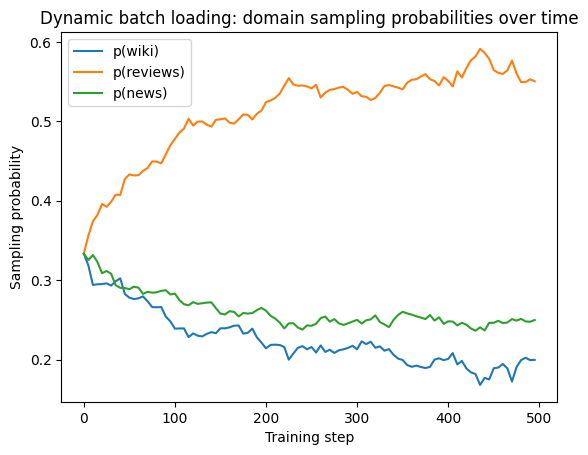

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(log_path)

# Find all probability columns
p_cols = [c for c in df.columns if c.startswith("p_")]
df = df.sort_values("step")

plt.figure()
for c in p_cols:
    plt.plot(df["step"], df[c], label=c.replace("p_", "p(") + ")")

plt.xlabel("Training step")
plt.ylabel("Sampling probability")
plt.title("Dynamic batch loading: domain sampling probabilities over time")
plt.legend()
plt.show()

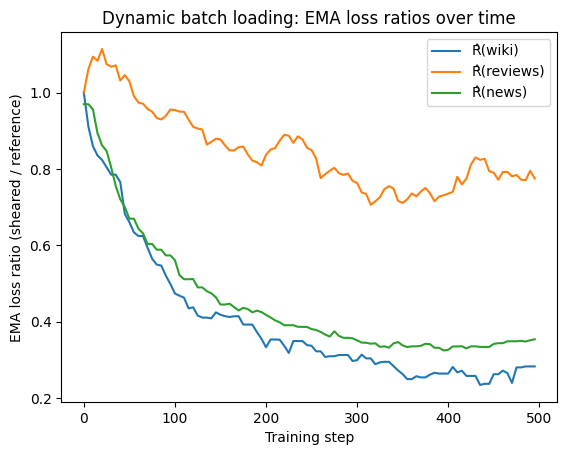

In [ ]:
r_cols = [c for c in df.columns if c.startswith("Rhat_")]

plt.figure()
for c in r_cols:
    plt.plot(df["step"], df[c], label=c.replace("Rhat_", "R̂(") + ")")

plt.xlabel("Training step")
plt.ylabel("EMA loss ratio (sheared / reference)")
plt.title("Dynamic batch loading: EMA loss ratios over time")
plt.legend()
plt.show()

###Comparison Tables

In [ ]:
import os, time, math
import torch
import pandas as pd
from datasets import load_dataset
from transformers import GPT2LMHeadModel, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

ROOT_DIR = "/content/drive/MyDrive/sheared_gpt2_project"
PRUNED_DIR = f"{ROOT_DIR}/sheared_gpt2_layers_ffn_10k"
PRUNED_DBL_DIR = f"{ROOT_DIR}/sheared_gpt2_layers_ffn_10k_dynamic"

# ---------- helpers ----------
def count_params_m(model):
    return sum(p.numel() for p in model.parameters()) / 1e6

def load_wikitext2_test(max_samples=200, max_length=128):
    tok = AutoTokenizer.from_pretrained("gpt2")
    tok.pad_token = tok.eos_token
    ds = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    texts = ds["text"][:max_samples]
    enc = tok(texts, truncation=True, max_length=max_length, padding="max_length", return_tensors="pt")
    return tok, enc["input_ids"], enc["attention_mask"]

def perplexity(model, input_ids, attention_mask, batch_size=8):
    model.eval()
    n = input_ids.size(0)
    total_loss = 0.0
    total_batches = 0
    with torch.no_grad():
        for i in range(0, n, batch_size):
            ids = input_ids[i:i+batch_size].to(device)
            mask = attention_mask[i:i+batch_size].to(device)
            labels = ids.clone()
            loss = model(input_ids=ids, attention_mask=mask, labels=labels).loss
            total_loss += float(loss.item())
            total_batches += 1
    avg_loss = total_loss / max(total_batches, 1)
    return math.exp(avg_loss)

def tokens_per_sec(model, tok, prompt="The future of AI is", max_new_tokens=128, runs=3):
    model.eval()
    inputs = tok(prompt, return_tensors="pt").to(device)

    # warmup (important)
    with torch.no_grad():
        _ = model.generate(**inputs, max_new_tokens=16, do_sample=False)

    # timed runs
    times = []
    for _ in range(runs):
        torch.cuda.synchronize()
        t0 = time.time()
        with torch.no_grad():
            _ = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
        torch.cuda.synchronize()
        t1 = time.time()
        times.append(t1 - t0)

    # tokens/sec ≈ generated tokens / time
    avg_time = sum(times) / len(times)
    return max_new_tokens / avg_time

# ---------- load eval data ----------
tok, ids, mask = load_wikitext2_test(max_samples=200, max_length=128)
tok.pad_token = tok.eos_token

# ---------- load models ----------
models = [
    ("Baseline (GPT-2)", "gpt2"),
    ("Pruned (Sheared-10k)", PRUNED_DIR),
    ("Pruned + DBL", PRUNED_DBL_DIR),
]

rows = []
for name, path in models:
    print(f"\nLoading: {name} from {path}")
    model = GPT2LMHeadModel.from_pretrained(path).to(device)

    params_m = count_params_m(model)
    ppl = perplexity(model, ids, mask, batch_size=8)
    tps = tokens_per_sec(model, tok, max_new_tokens=128, runs=3)

    rows.append({
        "Model": name,
        "Params (M)": round(params_m, 2),
        "Perplexity (WikiText-2 test, 200 ex)": round(ppl, 2),
        "Tokens/sec (avg, greedy)": round(tps, 2),
    })

df = pd.DataFrame(rows)
df

Device: cuda


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...


Loading: Pruned (Sheared-10k) from /content/drive/MyDrive/sheared_gpt2_project/sheared_gpt2_layers_ffn_10k


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Loading: Pruned + DBL from /content/drive/MyDrive/sheared_gpt2_project/sheared_gpt2_layers_ffn_10k_dynamic


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


,Model,Params (M),"Perplexity (WikiText-2 test, 200 ex)","Tokens/sec (avg, greedy)"
0,Baseline (GPT-2),124.44,5516.66,59.85
1,Pruned (Sheared-10k),67.75,30.83,100.54
2,Pruned + DBL,67.75,6.47,446.82


Table 2 In Vs Out domain

In [ ]:
import math
import pandas as pd
import torch
from datasets import load_dataset
from transformers import GPT2LMHeadModel, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

ROOT_DIR = "/content/drive/MyDrive/sheared_gpt2_project"
PRUNED_DIR = f"{ROOT_DIR}/sheared_gpt2_layers_ffn_10k"
PRUNED_DBL_DIR = f"{ROOT_DIR}/sheared_gpt2_layers_ffn_10k_dynamic"

# ---------- Models ----------
MODEL_SPECS = [
    ("Baseline (GPT-2)", "gpt2"),
    ("Pruned (Sheared-10k)", PRUNED_DIR),
    ("Pruned + DBL", PRUNED_DBL_DIR),
]

# ---------- Datasets ----------
# In-domain (used during DBL):
DATASETS = [
    ("IN: WikiText-2 (test)",  "wikitext", "wikitext-2-raw-v1", "test", "text"),
    ("IN: Yelp (test)",        "yelp_review_full", None, "test", "text"),
    ("IN: AG News (test)",     "ag_news", None, "test", "text"),
    # Out-of-domain (not used in DBL):
    ("OOD: IMDB (test)",       "imdb", None, "test", "text"),
    ("OOD: SST-2 (val)",       "glue", "sst2", "validation", "sentence"),
    ("OOD: WikiText-103 (test)","wikitext", "wikitext-103-v1", "test", "text"),
]

MAX_SAMPLES = 500
MAX_LENGTH = 128
BATCH_SIZE = 8

# ---------- Tokenizer ----------
tok = AutoTokenizer.from_pretrained("gpt2")
tok.pad_token = tok.eos_token  # needed for padding

def load_texts(ds_name, subset, split, text_field, max_samples=500):
    if subset is None:
        ds = load_dataset(ds_name, split=split)
    else:
        ds = load_dataset(ds_name, subset, split=split)

    texts = ds[text_field][:max_samples]

    # Optional: drop empty strings (especially for wikitext)
    texts = [t for t in texts if isinstance(t, str) and len(t.strip()) > 0]
    return texts

def tokenize_texts(texts, tokenizer, max_length=128):
    enc = tokenizer(
        texts,
        truncation=True,
        max_length=max_length,
        padding="max_length",
        return_tensors="pt",
    )
    return enc["input_ids"], enc["attention_mask"]

def compute_ppl(model, input_ids, attention_mask, batch_size=8):
    model.eval()
    n = input_ids.size(0)
    total_loss = 0.0
    total_batches = 0

    with torch.no_grad():
        for i in range(0, n, batch_size):
            ids = input_ids[i:i+batch_size].to(device)
            mask = attention_mask[i:i+batch_size].to(device)

            # Mask out padding tokens from the loss
            labels = ids.clone()
            labels[mask == 0] = -100

            loss = model(input_ids=ids, attention_mask=mask, labels=labels).loss
            total_loss += float(loss.item())
            total_batches += 1

    avg_loss = total_loss / max(total_batches, 1)
    return math.exp(avg_loss)

# ---------- Load models once ----------
loaded_models = []
for mname, mpath in MODEL_SPECS:
    print(f"Loading model: {mname}")
    m = GPT2LMHeadModel.from_pretrained(mpath).to(device)
    loaded_models.append((mname, m))

# ---------- Build matrix ----------
table = {"Dataset": [d[0] for d in DATASETS]}

for mname, model in loaded_models:
    col = []
    for (dlabel, ds_name, subset, split, text_field) in DATASETS:
        print(f"Eval {mname} on {dlabel} ...")
        texts = load_texts(ds_name, subset, split, text_field, max_samples=MAX_SAMPLES)
        ids, mask = tokenize_texts(texts, tok, max_length=MAX_LENGTH)
        ppl = compute_ppl(model, ids, mask, batch_size=BATCH_SIZE)
        col.append(ppl)
    table[mname] = col

df = pd.DataFrame(table)

# Nice formatting for slides
for c in df.columns[1:]:
    df[c] = df[c].map(lambda x: f"{x:.2f}")

df

Device: cuda
Loading model: Baseline (GPT-2)
Loading model: Pruned (Sheared-10k)
Loading model: Pruned + DBL
Eval Baseline (GPT-2) on IN: WikiText-2 (test) ...
Eval Baseline (GPT-2) on IN: Yelp (test) ...
Eval Baseline (GPT-2) on IN: AG News (test) ...
Eval Baseline (GPT-2) on OOD: IMDB (test) ...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Eval Pruned (Sheared-10k) on IN: WikiText-2 (test) ...
Eval Pruned (Sheared-10k) on IN: Yelp (test) ...
Eval Pruned (Sheared-10k) on IN: AG News (test) ...
Eval Pruned (Sheared-10k) on OOD: IMDB (test) ...
Eval Pruned (Sheared-10k) on OOD: SST-2 (val) ...
Eval Pruned (Sheared-10k) on OOD: WikiText-103 (test) ...
Eval Pruned + DBL on IN: WikiText-2 (test) ...
Eval Pruned + DBL on IN: Yelp (test) ...
Eval Pruned + DBL on IN: AG News (test) ...
Eval Pruned + DBL on OOD: IMDB (test) ...
Eval Pruned + DBL on OOD: SST-2 (val) ...
Eval Pruned + DBL on OOD: WikiText-103 (test) ...


,Dataset,Baseline (GPT-2),Pruned (Sheared-10k),Pruned + DBL
0,IN: WikiText-2 (test),70.82,26972.91,278.44
1,IN: Yelp (test),45.28,28190.49,112.48
2,IN: AG News (test),68.95,41801.24,252.68
3,OOD: IMDB (test),44.64,24326.89,258.96
4,OOD: SST-2 (val),176.10,22378.18,568.73
5,OOD: WikiText-103 (test),71.37,29603.53,281.00
